# Prédiction des Foyers de Peste des Petits Ruminants (PPR) au Cameroun

**Système d'alerte précoce PPR**

## Objectif
Construire un système d'alerte précoce capable de classifier le niveau de risque d'un arrondissement en 3 classes, à partir de données spatiales, temporelles, climatiques et épidémiologiques, avec une anticipation d'au moins 4 semaines avant la semaine épidémiologique critique estimée.

**Variable cible : `Diagnosis_basis`** (statut du foyer)
- `sans suspicion` → encodée **2**
- `Suspicion` → encodée **1**
- `Confirmé` → encodée **0**

## Pipeline du projet
1. **Exploration des données (EDA)** — comprendre la structure, la qualité et les signaux du dataset
2. **Prétraitement** — nettoyage, encodage, feature engineering, split spatio-temporel
3. **Modélisation** — ranking de plusieurs modèles, sélection des 2 meilleurs, ensemble par vote (soft voting)
4. **Évaluation & test** — précision, rappel, F1, matrices de confusion, courbes d'apprentissage, interprétabilité
5. **Documentation** — synthèse méthodologique et recommandations

---


# 1. Exploration des données (EDA)

Cette section a pour but de comprendre en profondeur le dataset avant toute transformation : structure, qualité, distribution de la cible, patterns temporels, géographiques et climatiques, et relations entre variables. Chaque observation ici guidera les choix faits en prétraitement et en modélisation.


## 1.1 Chargement et structure générale

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', None)

df = pd.read_excel('Data_PPR.xlsx')
print(f"Dimensions du dataset : {df.shape[0]} lignes x {df.shape[1]} colonnes")
df.head()


Dimensions du dataset : 4449 lignes x 18 colonnes


,Region,Arrondissement,Month,Year,PRECTOTCORR,PRECTOTCORR_SUM,RH2M,T2M,T2M_MAX,T2M_MIN,WD10M,WS10M,ZAE,EPI_week,Sick_animals,Susceptible_cases,Dead_animals,Diagnosis_basis
0,Sud-Ouest,Akwaya,February,2023,0.15325,0.15325,46.644,24.468625,34.754625,14.960875,58.355,3.047125,ZAE2_ZAE3,1,0,0,0,sans suspicion
1,Sud-Ouest,Akwaya,February,2023,0.15325,0.15325,46.644,24.468625,34.754625,14.960875,58.355,3.047125,ZAE2_ZAE3,2,0,0,0,sans suspicion
2,Sud-Ouest,Akwaya,February,2023,0.15325,0.15325,46.644,24.468625,34.754625,14.960875,58.355,3.047125,ZAE2_ZAE3,3,0,0,0,sans suspicion
3,Sud-Ouest,Akwaya,February,2023,0.15325,0.15325,46.644,24.468625,34.754625,14.960875,58.355,3.047125,ZAE2_ZAE3,4,0,0,0,sans suspicion
4,Sud-Ouest,Akwaya,February,2023,0.15325,0.15325,46.644,24.468625,34.754625,14.960875,58.355,3.047125,ZAE2_ZAE3,5,0,0,0,sans suspicion


In [2]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4449 entries, 0 to 4448
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Region             4449 non-null   object 
 1   Arrondissement     4449 non-null   object 
 2   Month              4449 non-null   object 
 3   Year               4449 non-null   int64  
 4   PRECTOTCORR        4449 non-null   float64
 5   PRECTOTCORR_SUM    4449 non-null   float64
 6   RH2M               4449 non-null   float64
 7   T2M                4449 non-null   float64
 8   T2M_MAX            4449 non-null   float64
 9   T2M_MIN            4449 non-null   float64
 10  WD10M              4449 non-null   float64
 11  WS10M              4449 non-null   float64
 12  ZAE                4449 non-null   object 
 13  EPI_week           4449 non-null   int64  
 14  Sick_animals       4449 non-null   int64  
 15  Susceptible_cases  4449 non-null   int64  
 16  Dead_animals       4449 

**Observation.** Le dataset brut contient 18 colonnes (variables géographiques, temporelles, climatiques et épidémiologiques). Les variables dérivées mentionnées dans le dictionnaire de données (encodages, composantes cycliques, `target`) n'existent pas encore : elles seront construites lors du prétraitement.

## 1.2 Qualité des données

In [3]:
# Valeurs manquantes
print("--- Valeurs manquantes par colonne ---")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "Aucune valeur manquante.")

# Doublons
n_dup = df.duplicated().sum()
print(f"\n--- Lignes dupliquées : {n_dup} ---")
if n_dup > 0:
    display(df[df.duplicated(keep=False)].sort_values(list(df.columns)))


--- Valeurs manquantes par colonne ---
Aucune valeur manquante.

--- Lignes dupliquées : 2 ---


,Region,Arrondissement,Month,Year,PRECTOTCORR,PRECTOTCORR_SUM,RH2M,T2M,T2M_MAX,T2M_MIN,WD10M,WS10M,ZAE,EPI_week,Sick_animals,Susceptible_cases,Dead_animals,Diagnosis_basis
4274,Centre,Yaoundé 6,August,2021,209.630238,209.630238,82.677143,25.18631,31.674762,20.747857,241.116667,2.283214,ZAE1,35,2,4,0,Confirmé
4275,Centre,Yaoundé 6,August,2021,209.630238,209.630238,82.677143,25.18631,31.674762,20.747857,241.116667,2.283214,ZAE1,35,2,4,0,Confirmé
4075,Sud-Ouest,Tiko,November,2021,2.472500,2.472500,78.131500,23.69900,31.293000,17.653000,113.360000,1.903500,ZAE3,48,50,50,0,Suspicion
4076,Sud-Ouest,Tiko,November,2021,2.472500,2.472500,78.131500,23.69900,31.293000,17.653000,113.360000,1.903500,ZAE3,48,50,50,0,Suspicion


In [4]:
# Cohérence physique des variables climatiques
print("--- Vérification de cohérence physique ---")
print(f"PRECTOTCORR (précipitation) min = {df['PRECTOTCORR'].min():.3f} -> devrait être >= 0")
n_neg_precip = (df['PRECTOTCORR'] < 0).sum()
print(f"Nombre de valeurs négatives de précipitation : {n_neg_precip} ({n_neg_precip/len(df)*100:.2f}%)")

print(f"\nRH2M (humidité relative) range : [{df['RH2M'].min():.2f}, {df['RH2M'].max():.2f}] -> attendu [0,100]")
print(f"T2M_MIN <= T2M <= T2M_MAX toujours respecté : {(df['T2M_MIN'] <= df['T2M']).all() and (df['T2M'] <= df['T2M_MAX']).all()}")

print(f"\nSick_animals >= Dead_animals toujours vrai : {(df['Sick_animals'] >= df['Dead_animals']).all()}")
n_incoherent = (df['Sick_animals'] < df['Dead_animals']).sum()
print(f"Lignes où Dead_animals > Sick_animals : {n_incoherent}")


--- Vérification de cohérence physique ---
PRECTOTCORR (précipitation) min = -1.225 -> devrait être >= 0
Nombre de valeurs négatives de précipitation : 104 (2.34%)

RH2M (humidité relative) range : [19.64, 90.08] -> attendu [0,100]
T2M_MIN <= T2M <= T2M_MAX toujours respecté : True

Sick_animals >= Dead_animals toujours vrai : False
Lignes où Dead_animals > Sick_animals : 2


**Observation.** Aucune valeur manquante et très peu de doublons (négligeables). En revanche, `PRECTOTCORR` présente quelques valeurs négatives, physiquement impossibles pour une précipitation — probablement un artefact d'interpolation des données satellite NASA POWER. Ce point sera corrigé en prétraitement (clip à 0). Les autres variables sont cohérentes.

## 1.3 Analyse de la variable cible

                 Effectif  Pourcentage (%)
Diagnosis_basis                           
sans suspicion       4271            96.00
Suspicion             157             3.53
Confirmé               21             0.47


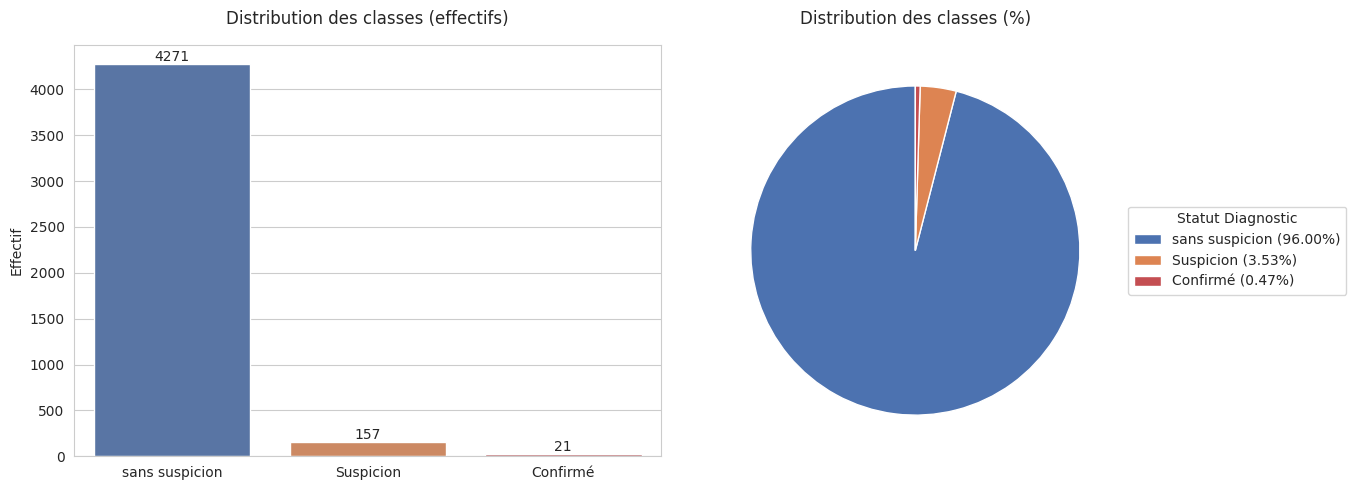

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculs et résumé
target_counts = df['Diagnosis_basis'].value_counts()
target_pct = df['Diagnosis_basis'].value_counts(normalize=True) * 100

summary_target = pd.DataFrame({'Effectif': target_counts, 'Pourcentage (%)': target_pct.round(2)})
print(summary_target)

# 2. Configuration de la figure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
order = ['sans suspicion', 'Suspicion', 'Confirmé']
colors = ['#4C72B0', '#DD8452', '#C44E52']

# --- Graphique 1 : Countplot (les labels sont déjà sur l'axe X) ---
sns.countplot(data=df, x='Diagnosis_basis', order=order, palette=colors, ax=axes[0])
axes[0].set_title("Distribution des classes (effectifs)", pad=15)
axes[0].set_xlabel("")
axes[0].set_ylabel("Effectif")

# Ajout des étiquettes au-dessus des barres
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', 
                     (p.get_x() + p.get_width() / 2, p.get_height()), 
                     ha='center', va='bottom', fontsize=10)

# --- Graphique 2 : Pie Chart (avec Légende à droite) ---
# --- Graphique 2 : Pie Chart (Propre et sans chevauchement) ---

# 1. On calcule les pourcentages exacts pour les ajouter dans la légende
percentages = target_pct[order].values
# Création de labels personnalisés pour la légende (ex: "sans suspicion (96.00%)")
legend_labels = [f'{label} ({pct:.2f}%)' for label, pct in zip(order, percentages)]

# 2. On génère le pie chart SANS afficher de texte dessus (autopct=None)
wedges, texts = axes[1].pie(
    target_counts[order], 
    labels=None, 
    colors=colors, 
    startangle=90,
    wedgeprops=dict(edgecolor='w', linewidth=1) # Ajoute une fine ligne blanche de séparation
)

axes[1].set_title("Distribution des classes (%)", pad=15)

# 3. Légende contenant à la fois le nom et le pourcentage
axes[1].legend(
    wedges, 
    legend_labels, # Utilisation de nos labels personnalisés
    title="Statut Diagnostic",
    loc="center left",
    bbox_to_anchor=(1, 0.5) 
)

# Ajustement et affichage
plt.tight_layout()
plt.show()

**Observation critique.** Le déséquilibre de classes est **extrême** : la classe majoritaire `sans suspicion` représente ~96% des observations, contre seulement ~3.5% pour `Suspicion` et **0.5% (21 cas)** pour `Confirmé`. 

Ceci a des implications majeures pour la suite du pipeline :
- Un split spatio-temporel naïf risque de laisser certains folds sans aucun exemple de la classe `Confirmé`
- L'accuracy sera un indicateur trompeur ; il faudra privilégier le F1-score macro/pondéré, le rappel par classe et la matrice de confusion
- Des stratégies de rééquilibrage (SMOTE, pondération des classes, seuils de décision) seront indispensables en modélisation
- La validation croisée devra être stratifiée (`GroupKFold` combiné à une stratification si possible) pour garantir la présence de chaque classe dans chaque fold


## 1.4 Analyse temporelle

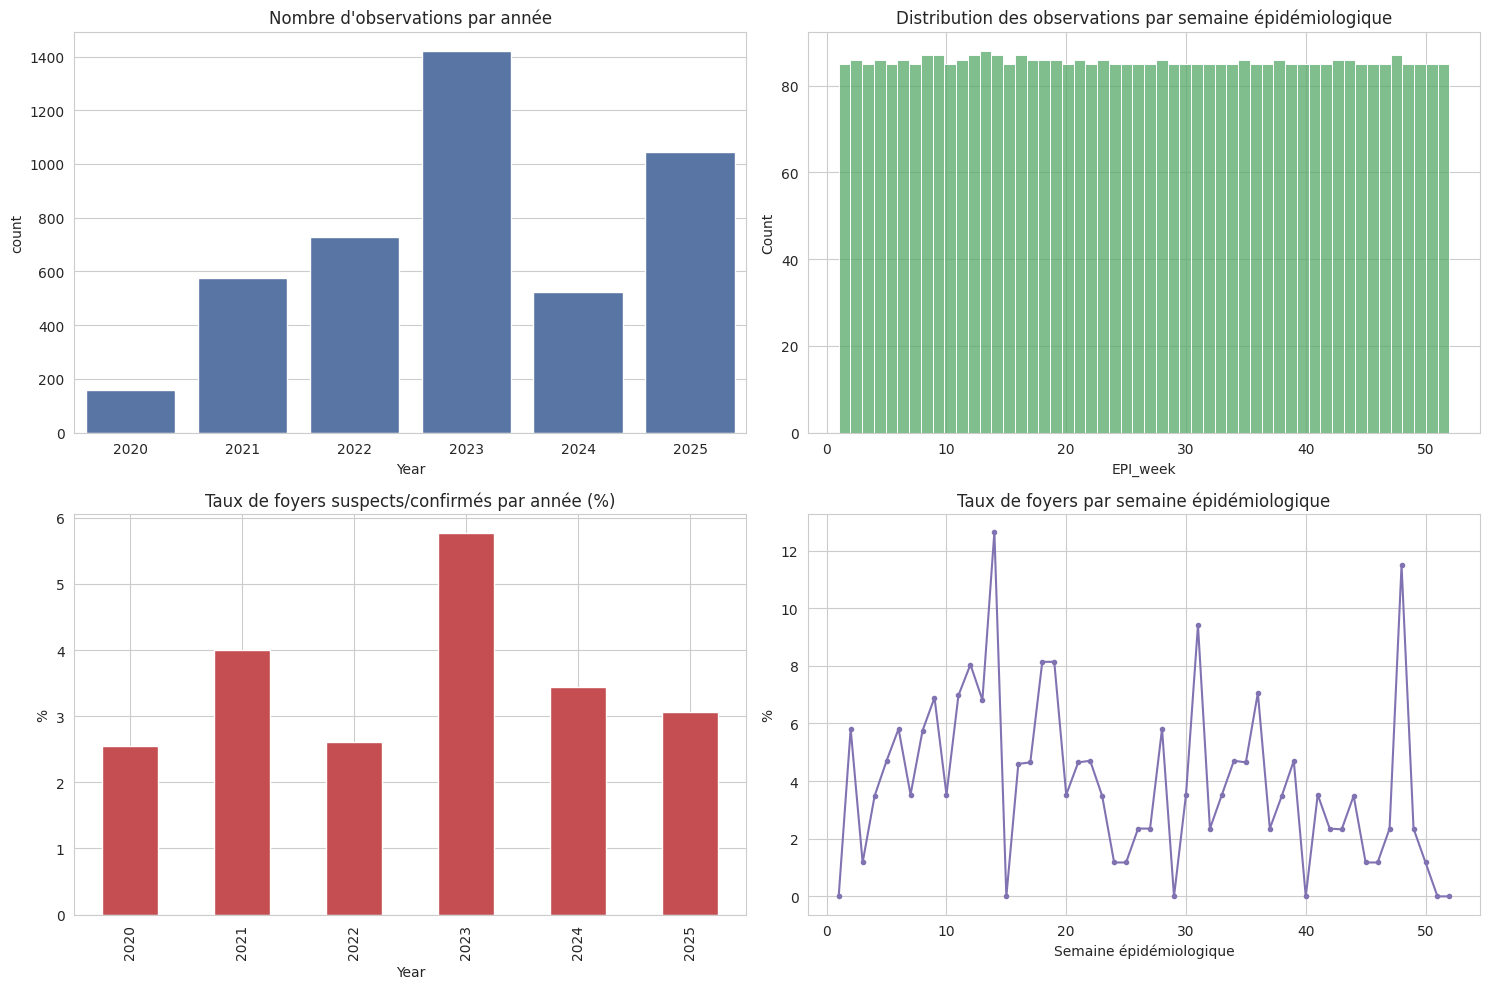

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Distribution par année
sns.countplot(data=df, x='Year', ax=axes[0,0], color='#4C72B0')
axes[0,0].set_title("Nombre d'observations par année")

# Distribution par semaine épidémiologique
sns.histplot(data=df, x='EPI_week', bins=52, ax=axes[0,1], color='#55A868')
axes[0,1].set_title("Distribution des observations par semaine épidémiologique")

# Taux de foyers (Suspicion + Confirmé) par année
df['is_foyer'] = df['Diagnosis_basis'].isin(['Suspicion', 'Confirmé'])
foyer_by_year = df.groupby('Year')['is_foyer'].mean() * 100
foyer_by_year.plot(kind='bar', ax=axes[1,0], color='#C44E52')
axes[1,0].set_title("Taux de foyers suspects/confirmés par année (%)")
axes[1,0].set_ylabel('%')

# Taux de foyers par semaine épidémiologique (moyenne mobile)
foyer_by_week = df.groupby('EPI_week')['is_foyer'].mean() * 100
axes[1,1].plot(foyer_by_week.index, foyer_by_week.values, marker='o', markersize=3, color='#8172B2')
axes[1,1].set_title("Taux de foyers par semaine épidémiologique")
axes[1,1].set_xlabel('Semaine épidémiologique')
axes[1,1].set_ylabel('%')

plt.tight_layout()
plt.show()


**Observation.** On regarde ici s'il existe une **saisonnalité** dans l'apparition des foyers — un signal important puisque le PPR est connu pour être influencé par les mouvements de transhumance et les conditions climatiques saisonnières. Les pics de taux de foyers par semaine épidémiologique, s'ils sont récurrents d'une année sur l'autre, justifieront l'encodage cyclique (`week_sin`/`week_cos`) prévu dans le dictionnaire de données.

## 1.5 Analyse géographique

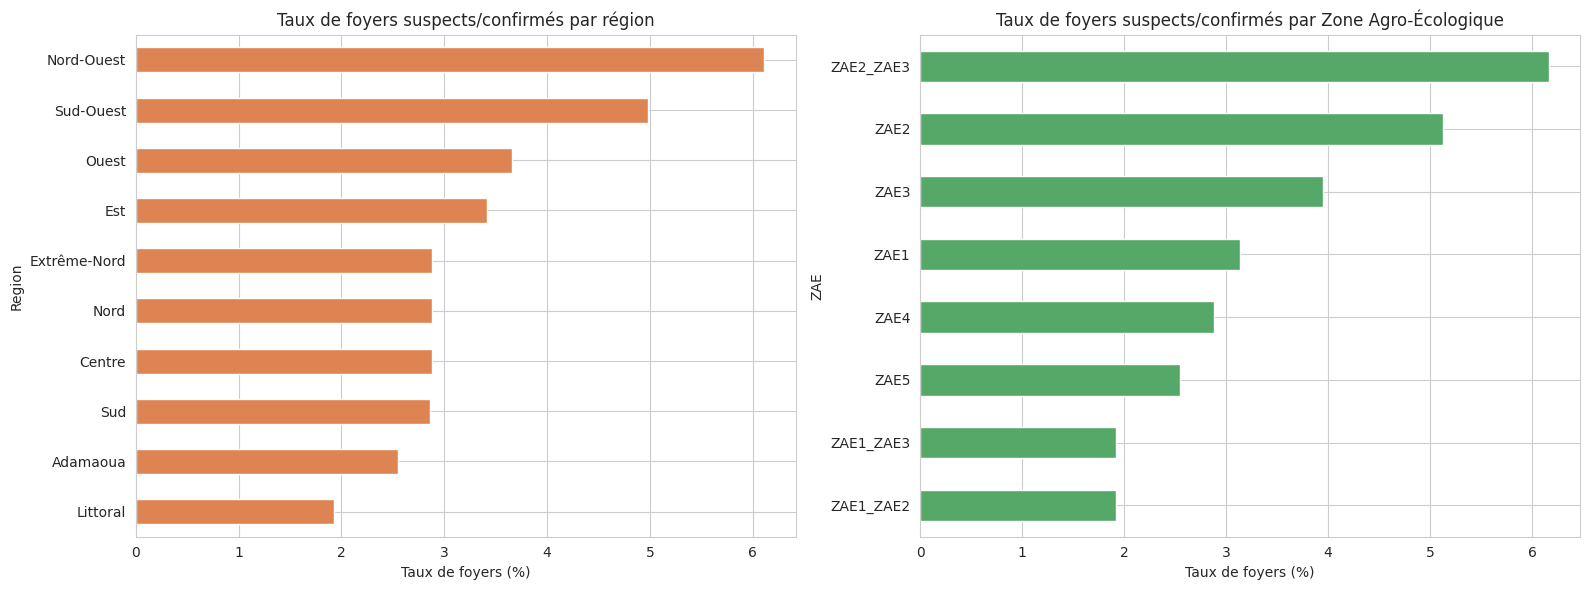

--- Détail par région (effectif, taux de foyers %) ---
              taux_foyer_%  n_obs
Region                           
Nord-Ouest        6.113537    687
Sud-Ouest         4.986401   1103
Ouest             3.658537    574
Est               3.411514    469
Extrême-Nord      2.884615    104
Nord              2.884615    312
Centre            2.880000    625
Sud               2.857143    105
Adamaoua          2.547771    314
Littoral          1.923077    156


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Taux de foyers par région
region_risk = df.groupby('Region')['is_foyer'].agg(['mean', 'count']).sort_values('mean', ascending=False)
region_risk['mean'] = region_risk['mean'] * 100
region_risk['mean'].plot(kind='barh', ax=axes[0], color='#DD8452')
axes[0].set_xlabel('Taux de foyers (%)')
axes[0].set_title('Taux de foyers suspects/confirmés par région')
axes[0].invert_yaxis()

# Taux de foyers par ZAE
zae_risk = df.groupby('ZAE')['is_foyer'].agg(['mean', 'count']).sort_values('mean', ascending=False)
zae_risk['mean'] = zae_risk['mean'] * 100
zae_risk['mean'].plot(kind='barh', ax=axes[1], color='#55A868')
axes[1].set_xlabel('Taux de foyers (%)')
axes[1].set_title('Taux de foyers suspects/confirmés par Zone Agro-Écologique')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("--- Détail par région (effectif, taux de foyers %) ---")
print(region_risk.rename(columns={'mean':'taux_foyer_%','count':'n_obs'}))


In [10]:
# Top arrondissements les plus à risque (avec un minimum d'observations pour être significatif)
arr_risk = df.groupby('Arrondissement')['is_foyer'].agg(['mean', 'count'])
arr_risk = arr_risk[arr_risk['count'] >= 10].sort_values('mean', ascending=False)
arr_risk['mean'] = (arr_risk['mean'] * 100).round(2)
arr_risk.columns = ['taux_foyer_%', 'n_obs']
print(f"Nombre d'arrondissements distincts : {df['Arrondissement'].nunique()}")
print("\nTop 10 arrondissements les plus à risque (>= 10 observations) :")
print(arr_risk.head(10))
print("\nNombre d'arrondissements avec au moins un foyer (Suspicion/Confirmé) :", (df.groupby('Arrondissement')['is_foyer'].sum() > 0).sum())


Nombre d'arrondissements distincts : 61

Top 10 arrondissements les plus à risque (>= 10 observations) :
                taux_foyer_%  n_obs
Arrondissement                     
Oku                    19.30     57
Mbven                  14.55     55
Akwaya                 14.55     55
Tiko                    8.75    160
Fundong                 8.41    107
Salapoumbe              7.69     52
Bafoussam 2             7.69     52
Kumba 3                 7.11    211
Yokadouma               5.77     52
Koutaba                 5.77     52

Nombre d'arrondissements avec au moins un foyer (Suspicion/Confirmé) : 61


**Observation.** Le risque de foyer n'est pas uniformément réparti géographiquement : certaines régions/ZAE concentrent une proportion nettement plus élevée de cas suspects ou confirmés. Ceci confirme la pertinence d'inclure la géographie (région, ZAE, arrondissement) comme variable prédictive forte, et justifie l'usage d'un **split spatio-temporel** (plutôt qu'un split aléatoire) pour éviter les fuites d'information entre arrondissements voisins d'une même série temporelle.

## 1.6 Analyse des variables climatiques

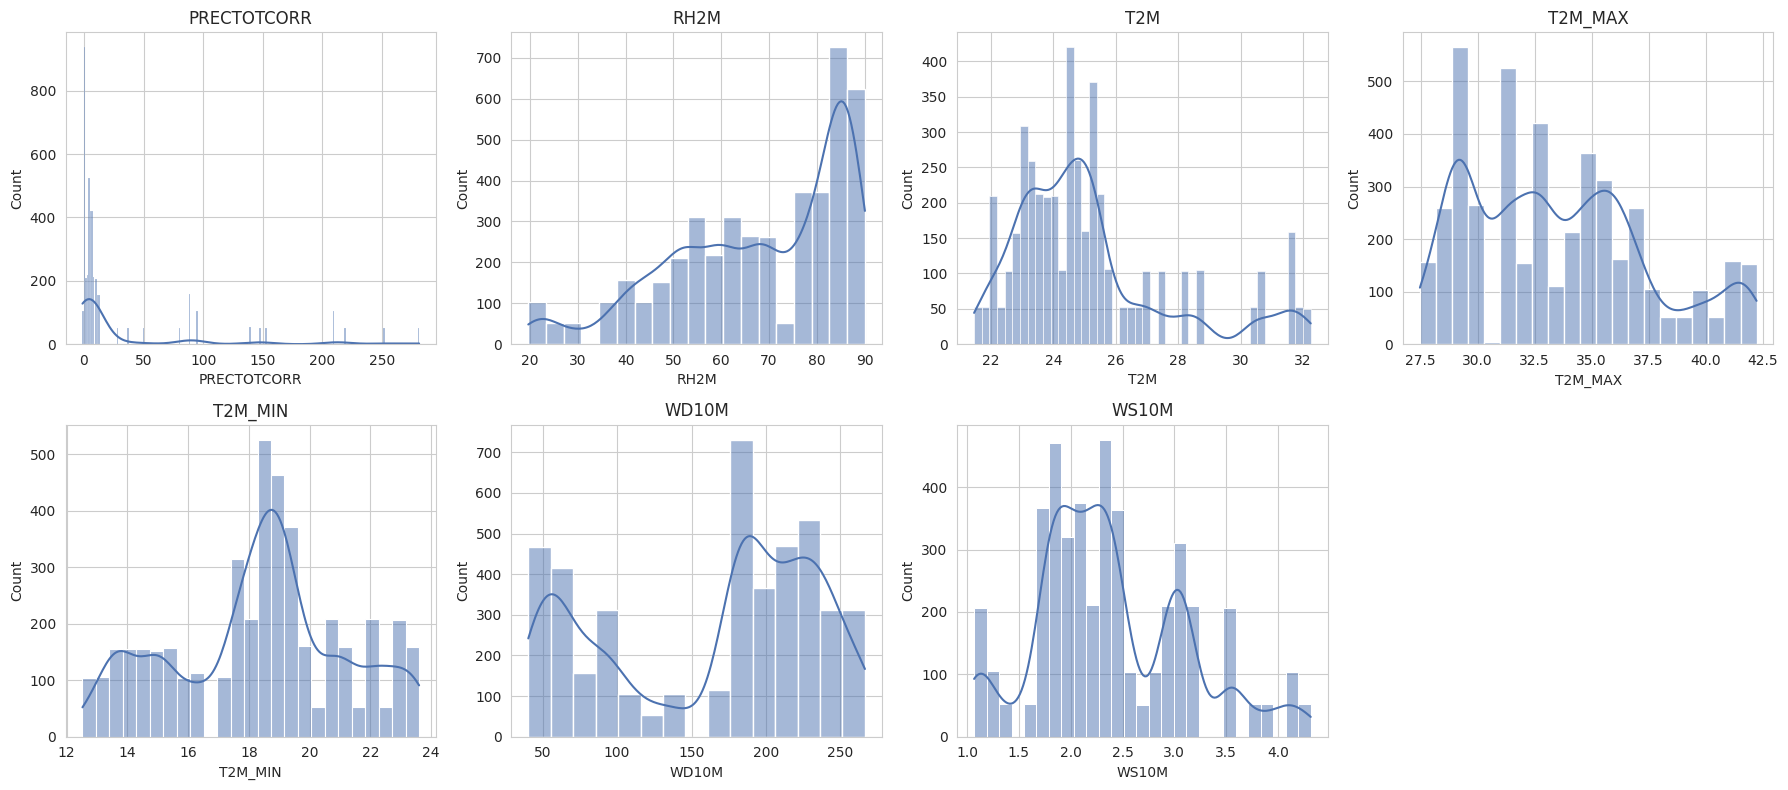

In [11]:
climate_vars = ['PRECTOTCORR', 'RH2M', 'T2M', 'T2M_MAX', 'T2M_MIN', 'WD10M', 'WS10M']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, var in enumerate(climate_vars):
    sns.histplot(df[var], kde=True, ax=axes[i], color='#4C72B0')
    axes[i].set_title(var)
axes[-1].axis('off')
plt.tight_layout()
plt.show()


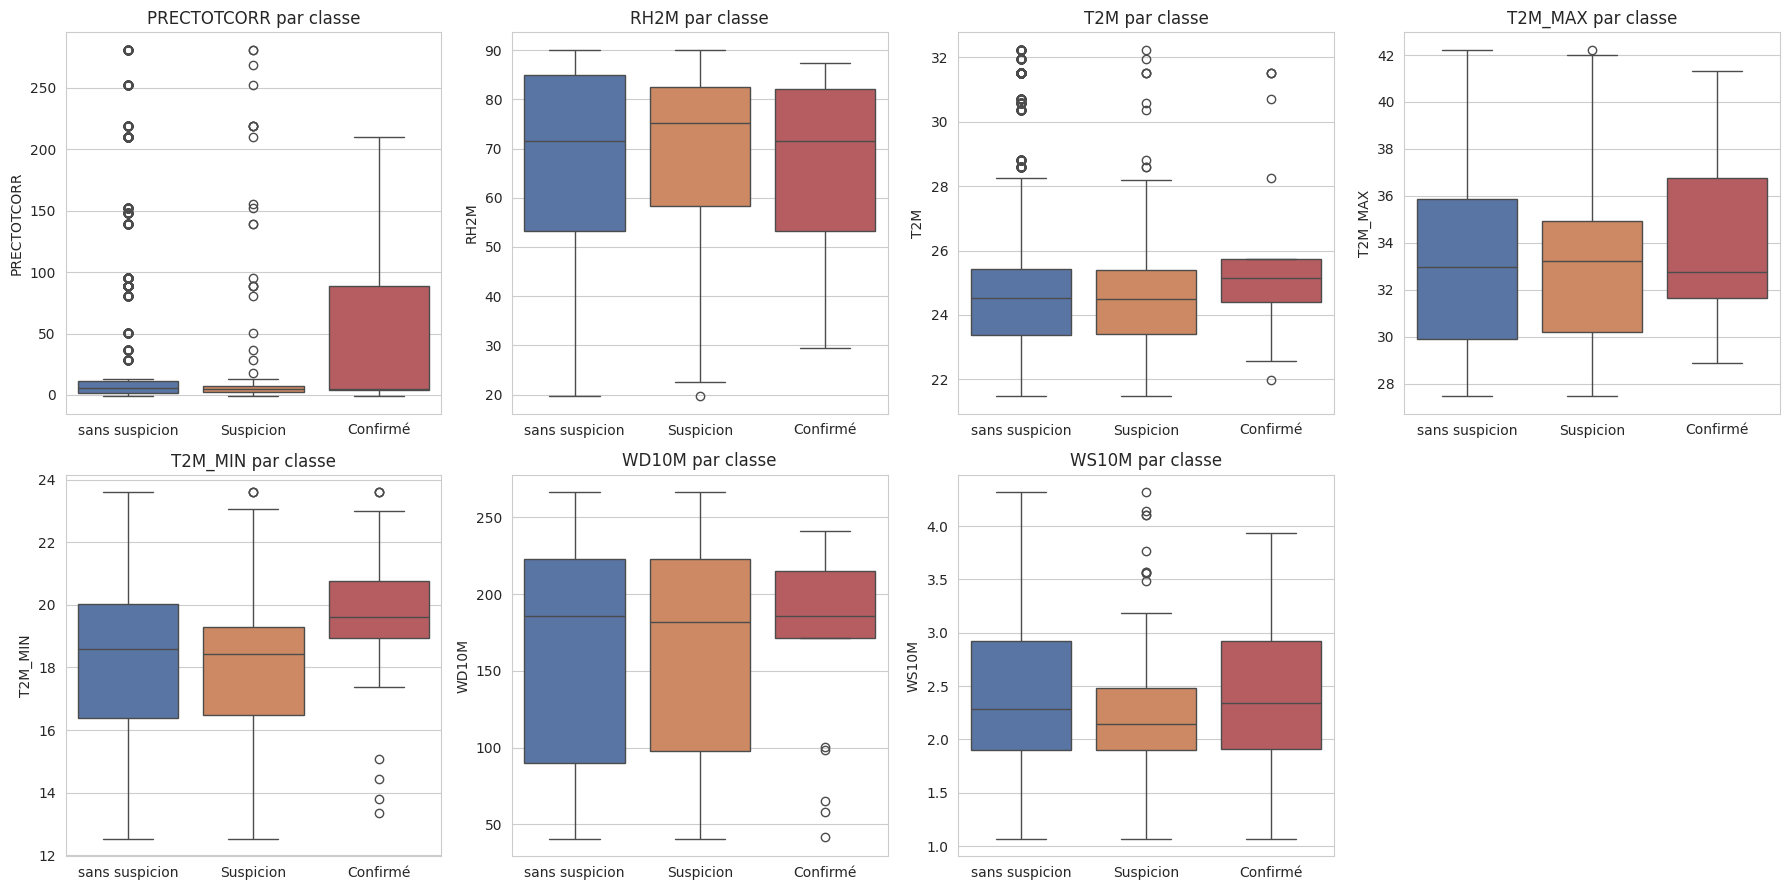

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
order = ['sans suspicion', 'Suspicion', 'Confirmé']
for i, var in enumerate(climate_vars):
    sns.boxplot(data=df, x='Diagnosis_basis', y=var, order=order, ax=axes[i], palette=colors)
    axes[i].set_title(f'{var} par classe')
    axes[i].set_xlabel('')
axes[-1].axis('off')
plt.tight_layout()
plt.show()


**Observation.** On compare ici la distribution de chaque variable climatique selon la classe de la cible. Des écarts marqués de médiane/dispersion pour `Suspicion`/`Confirmé` par rapport à `sans suspicion` indiqueraient un signal climatique exploitable (ex : précipitations et humidité sont des facteurs connus de survie du virus PPR dans l'environnement et de densité des points d'abreuvement favorisant le contact entre animaux).

## 1.7 Variables épidémiologiques et corrélations

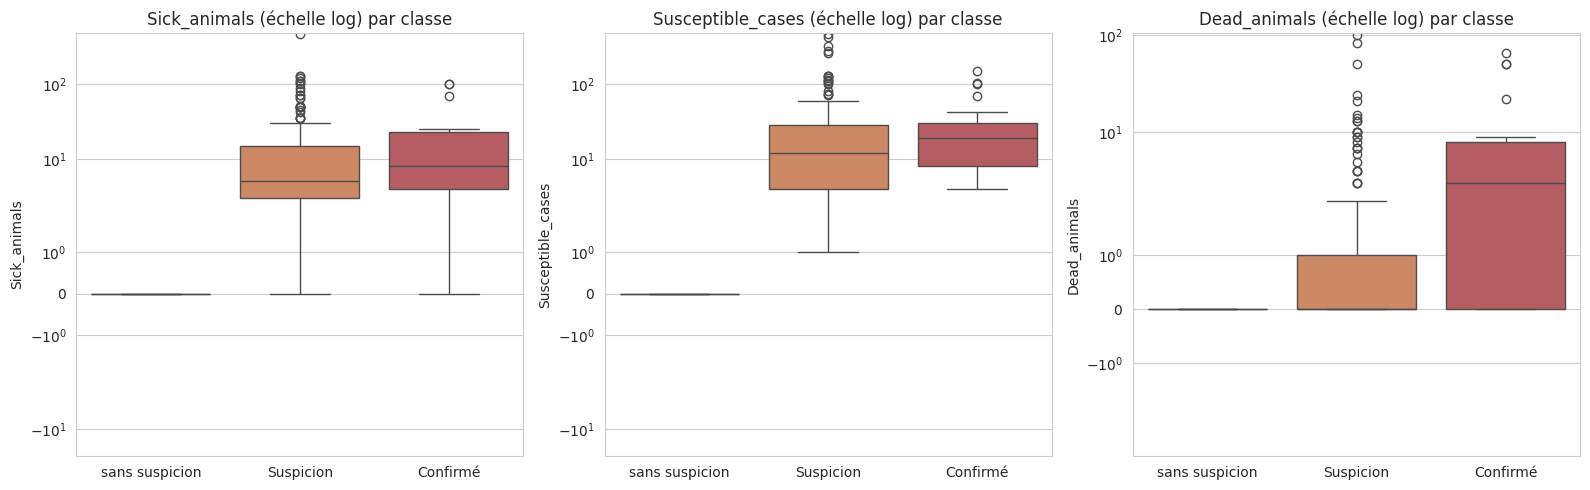

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, var in enumerate(['Sick_animals', 'Susceptible_cases', 'Dead_animals']):
    sns.boxplot(data=df, x='Diagnosis_basis', y=var, order=order, ax=axes[i], palette=colors)
    axes[i].set_yscale('symlog')
    axes[i].set_title(f'{var} (échelle log) par classe')
    axes[i].set_xlabel('')
plt.tight_layout()
plt.show()


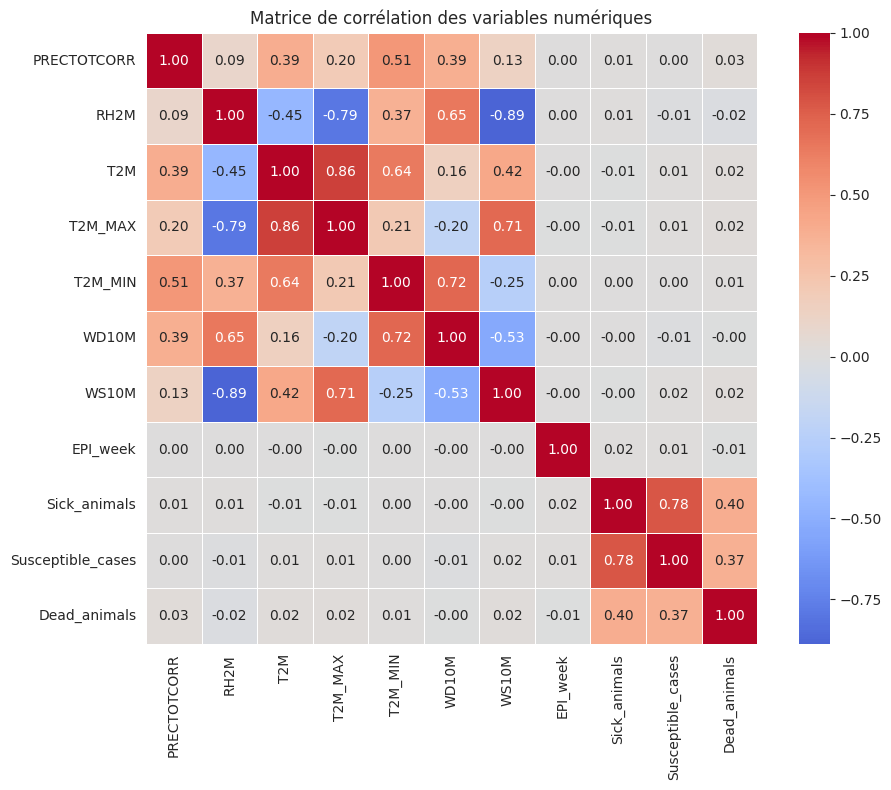

In [14]:
# Matrice de corrélation des variables numériques
num_cols = ['PRECTOTCORR', 'RH2M', 'T2M', 'T2M_MAX', 'T2M_MIN', 'WD10M', 'WS10M',
            'EPI_week', 'Sick_animals', 'Susceptible_cases', 'Dead_animals']
corr = df[num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Matrice de corrélation des variables numériques')
plt.tight_layout()
plt.show()


**Observation.** 
- Les variables `Sick_animals`, `Susceptible_cases` et `Dead_animals` sont potentiellement de **puissants indicateurs directs** du statut du foyer, mais attention : selon la manière dont ces compteurs sont mesurés, ils peuvent être disponibles seulement *après* le diagnostic (fuite de données / data leakage). Ce point devra être tranché explicitement en prétraitement.
- `T2M`, `T2M_MAX`, `T2M_MIN` sont naturellement très corrélées entre elles (redondance), de même que `PRECTOTCORR` et `PRECTOTCORR_SUM` qui semblent identiques. Cela guidera la sélection/réduction de variables pour limiter la multicolinéarité.


## 1.8 Synthèse de l'exploration des données

**Principaux enseignements de l'EDA, à reporter en prétraitement et en modélisation :**

1. **Déséquilibre de classes extrême** (96% / 3.5% / 0.5%) → nécessite SMOTE et/ou pondération des classes, métriques adaptées (F1 macro, rappel par classe), et une validation croisée stratifiée par groupes.
2. **Valeurs négatives aberrantes** sur `PRECTOTCORR` → à corriger (clip à 0).
3. **Colonnes redondantes** : `PRECTOTCORR` / `PRECTOTCORR_SUM` quasi-identiques, `T2M`/`T2M_MAX`/`T2M_MIN` fortement corrélées → à gérer via sélection de variables.
4. **Risque de data leakage potentiel** avec `Sick_animals`, `Susceptible_cases`, `Dead_animals` → à investiguer/traiter avec précaution (décision à documenter explicitement).
5. **Signal géographique fort** (région, ZAE, arrondissement) → split spatio-temporel nécessaire pour une évaluation honnête et respecter la contrainte d'anticipation de 4 semaines.
6. **Possible saisonnalité** → encodage cyclique de la semaine épidémiologique et du mois pertinent.
7. **Variables catégorielles** (`Region`, `Arrondissement`, `ZAE`, `Month`) → à encoder numériquement pour la modélisation.

 Nous allons maintenant passer à l'étape de **prétraitement**.


# 2. Prétraitement

On repart d'une copie fraîche du dataset brut pour garder cette section autonome et reproductible.

**Décisions prises (validées avec le porteur du projet) :**
- Les doublons exacts sont supprimés (approche standard).
- `Sick_animals`, `Susceptible_cases`, `Dead_animals` : en l'absence de certitude sur leur disponibilité *avant* le diagnostic, on adopte une **approche prudente en deux temps** :
  1. On les garde comme features dans un premier temps (hypothèse : ce sont des comptages remontés lors de l'alerte terrain, donc disponibles avant confirmation du diagnostic — cohérence avec l'objectif de "détection précoce" du challenge).
  2. On surveillera leur importance dans les modèles (étape 3-4) : si elles dominent de façon disproportionnée (signe de fuite de données), on refera tourner les modèles sans elles et on comparera, pour trancher en toute transparence dans la documentation finale.


## 2.1 Chargement propre et nettoyage

In [15]:
df_raw = pd.read_excel('Data_PPR.xlsx')
print(f"Avant nettoyage : {df_raw.shape}")

# Suppression des doublons exacts
df_clean = df_raw.drop_duplicates().reset_index(drop=True)
print(f"Après suppression des doublons : {df_clean.shape}")

# Suppression de la colonne redondante (identique à PRECTOTCORR)
assert df_clean['PRECTOTCORR'].equals(df_clean['PRECTOTCORR_SUM'])
df_clean = df_clean.drop(columns=['PRECTOTCORR_SUM'])

# Correction des précipitations négatives (artefact physique impossible)
n_neg = (df_clean['PRECTOTCORR'] < 0).sum()
df_clean['PRECTOTCORR'] = df_clean['PRECTOTCORR'].clip(lower=0)
print(f"Valeurs négatives de précipitation corrigées (clip à 0) : {n_neg}")

df_clean.shape


Avant nettoyage : (4449, 18)
Après suppression des doublons : (4447, 18)
Valeurs négatives de précipitation corrigées (clip à 0) : 104


(4447, 17)

## 2.2 Feature engineering temporel

In [16]:
month_map = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6,
    'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12
}
df_clean['Month_num'] = df_clean['Month'].map(month_map)
df_clean['Month_numeric'] = df_clean['Month_num']

# Encodage cyclique (semaine épidémiologique et mois) pour capturer la saisonnalité
# sans introduire de discontinuité artificielle entre semaine 52 et semaine 1
df_clean['week_sin'] = np.sin(2 * np.pi * df_clean['EPI_week'] / 52)
df_clean['week_cos'] = np.cos(2 * np.pi * df_clean['EPI_week'] / 52)
df_clean['month_sin'] = np.sin(2 * np.pi * df_clean['Month_numeric'] / 12)
df_clean['month_cos'] = np.cos(2 * np.pi * df_clean['Month_numeric'] / 12)

df_clean[['Month', 'Month_numeric', 'EPI_week', 'week_sin', 'week_cos']].head()


,Month,Month_numeric,EPI_week,week_sin,week_cos
0,February,2,1,0.120537,0.992709
1,February,2,2,0.239316,0.970942
2,February,2,3,0.354605,0.935016
3,February,2,4,0.464723,0.885456
4,February,2,5,0.568065,0.822984


## 2.3 Encodage des variables catégorielles géographiques

In [17]:
from sklearn.preprocessing import LabelEncoder

le_region = LabelEncoder()
le_zae = LabelEncoder()
le_arr = LabelEncoder()

df_clean['Region_encoded'] = le_region.fit_transform(df_clean['Region'])
df_clean['ZAE_encoded'] = le_zae.fit_transform(df_clean['ZAE'])
df_clean['Arrondissement_encoded'] = le_arr.fit_transform(df_clean['Arrondissement'])

print(f"Régions : {len(le_region.classes_)} catégories")
print(f"ZAE : {len(le_zae.classes_)} catégories")
print(f"Arrondissements : {len(le_arr.classes_)} catégories")

df_clean[['Region', 'Region_encoded', 'ZAE', 'ZAE_encoded', 'Arrondissement', 'Arrondissement_encoded']].head()


Régions : 10 catégories
ZAE : 8 catégories
Arrondissements : 61 catégories


,Region,Region_encoded,ZAE,ZAE_encoded,Arrondissement,Arrondissement_encoded
0,Sud-Ouest,9,ZAE2_ZAE3,4,Akwaya,0
1,Sud-Ouest,9,ZAE2_ZAE3,4,Akwaya,0
2,Sud-Ouest,9,ZAE2_ZAE3,4,Akwaya,0
3,Sud-Ouest,9,ZAE2_ZAE3,4,Akwaya,0
4,Sud-Ouest,9,ZAE2_ZAE3,4,Akwaya,0


**Note méthodologique.** Un encodage ordinal (`LabelEncoder`) est utilisé plutôt qu'un one-hot encoding : les modèles à base d'arbres retenus pour ce problème (Random Forest, XGBoost, LightGBM) gèrent nativement ce type d'encodage sans supposer d'ordre réel entre catégories, et cela évite une explosion dimensionnelle liée aux 61 arrondissements.

## 2.4 Variables dérivées épidémiologiques

In [18]:
# Ratios cliniques, avec gestion des divisions par zéro
df_clean['mortality_rate'] = np.where(
    df_clean['Sick_animals'] > 0,
    df_clean['Dead_animals'] / df_clean['Sick_animals'],
    0
)
df_clean['attack_rate'] = np.where(
    df_clean['Susceptible_cases'] > 0,
    df_clean['Sick_animals'] / df_clean['Susceptible_cases'],
    0
)

df_clean[['Sick_animals', 'Dead_animals', 'Susceptible_cases', 'mortality_rate', 'attack_rate']].describe()


,Sick_animals,Dead_animals,Susceptible_cases,mortality_rate,attack_rate
count,4447.000000,4447.000000,4447.000000,4447.000000,4447.000000
mean,0.774455,0.165730,1.323364,0.009762,0.026384
std,9.434610,2.677729,14.275131,0.144869,0.146780
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000
max,464.000000,100.000000,464.000000,8.333333,1.000000


## 2.5 Construction de la variable cible

In [19]:
target_mapping = {'Confirmé': 0, 'Suspicion': 1, 'sans suspicion': 2}
df_clean['target'] = df_clean['Diagnosis_basis'].map(target_mapping)

print("Mapping appliqué :", target_mapping)
print()
print(df_clean['target'].value_counts().sort_index())
print()
print(df_clean[['Diagnosis_basis', 'target']].drop_duplicates())


Mapping appliqué : {'Confirmé': 0, 'Suspicion': 1, 'sans suspicion': 2}

target
0      20
1     156
2    4271
Name: count, dtype: int64

   Diagnosis_basis  target
0   sans suspicion       2
5        Suspicion       1
92        Confirmé       0


## 2.6 Split spatio-temporel (train / test)

In [20]:
print("Répartition des observations par année :")
print(df_clean['Year'].value_counts().sort_index())
print()
print("Répartition des classes rares par année :")
print(pd.crosstab(df_clean['Year'], df_clean['Diagnosis_basis'])[['Confirmé', 'Suspicion']])


Répartition des observations par année :
Year
2020     157
2021     574
2022     729
2023    1421
2024     523
2025    1043
Name: count, dtype: int64

Répartition des classes rares par année :
Diagnosis_basis  Confirmé  Suspicion
Year                                
2020                    0          4
2021                    3         18
2022                    2         17
2023                    8         74
2024                    0         18
2025                    7         25


**Stratégie de split retenue.**

Un split aléatoire classique n'est pas adapté ici : il romprait l'ordre temporel et créerait des fuites d'information (le modèle "verrait" indirectement le futur pour prédire le passé), ce qui est incompatible avec la contrainte d'anticipation d'au moins 4 semaines demandée par le challenge.

On adopte donc un **split chronologique strict** :
- **Train** = années 2020 à 2024
- **Test (hold-out final)** = année 2025 entière

Ce découpage garantit que le test set est intégralement postérieur au train (donc largement au-delà des 4 semaines d'anticipation minimales exigées), tout en conservant un nombre suffisant d'exemples de chaque classe — y compris `Confirmé` — dans le test set pour une évaluation significative.

Pour la sélection de modèles et le réglage des hyperparamètres (étape 3), on utilisera en complément une **validation croisée groupée par arrondissement** (`GroupKFold`) sur le train set, afin de vérifier la robustesse spatiale des modèles (un arrondissement du fold de validation n'apparaît jamais dans le fold d'entraînement correspondant).


In [21]:
feature_cols = [
    'PRECTOTCORR', 'RH2M', 'T2M', 'T2M_MAX', 'T2M_MIN', 'WD10M', 'WS10M',
    'Year', 'EPI_week', 'Month_numeric', 'week_sin', 'week_cos', 'month_sin', 'month_cos',
    'Region_encoded', 'ZAE_encoded', 'Arrondissement_encoded',
    'Sick_animals', 'Susceptible_cases', 'Dead_animals', 'mortality_rate', 'attack_rate'
]

train_df = df_clean[df_clean['Year'] <= 2024].reset_index(drop=True)
test_df = df_clean[df_clean['Year'] == 2025].reset_index(drop=True)

X_train = train_df[feature_cols]
y_train = train_df['target']
groups_train = train_df['Arrondissement']  # pour GroupKFold

X_test = test_df[feature_cols]
y_test = test_df['target']

print(f"Train : {X_train.shape[0]} lignes | Test : {X_test.shape[0]} lignes")
print(f"\nDistribution des classes - Train :\n{y_train.value_counts(normalize=True).sort_index().round(4)}")
print(f"\nDistribution des classes - Test :\n{y_test.value_counts(normalize=True).sort_index().round(4)}")


Train : 3404 lignes | Test : 1043 lignes

Distribution des classes - Train :
target
0    0.0038
1    0.0385
2    0.9577
Name: proportion, dtype: float64

Distribution des classes - Test :
target
0    0.0067
1    0.0240
2    0.9693
Name: proportion, dtype: float64


## 2.7 Standardisation des variables numériques

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=feature_cols, index=X_test.index)

print("Standardisation appliquée (moyenne 0, écart-type 1), ajustée uniquement sur le train (pas de fuite d'information).")
X_train_scaled.describe().loc[['mean', 'std']].round(2)


Standardisation appliquée (moyenne 0, écart-type 1), ajustée uniquement sur le train (pas de fuite d'information).


,PRECTOTCORR,RH2M,T2M,T2M_MAX,T2M_MIN,WD10M,WS10M,Year,EPI_week,Month_numeric,week_sin,week_cos,month_sin,month_cos,Region_encoded,ZAE_encoded,Arrondissement_encoded,Sick_animals,Susceptible_cases,Dead_animals,mortality_rate,attack_rate
mean,0.0,-0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,-0.0,0.0,-0.0,-0.0,0.0,0.0,-0.0,0.0,-0.0,0.0,0.0,0.0,0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


**Note.** Les versions standardisées (`X_train_scaled`, `X_test_scaled`) seront utilisées pour les modèles sensibles à l'échelle (régression logistique, SVM, MLP, KNN...), tandis que les versions non standardisées (`X_train`, `X_test`) seront utilisées pour les modèles à base d'arbres (Random Forest, XGBoost, LightGBM), qui sont invariants à l'échelle et pour lesquels la standardisation n'apporte rien.

## 2.8 Sauvegarde des jeux de données prétraités

In [23]:
import joblib

preprocessed_data = {
    'X_train': X_train, 'X_test': X_test,
    'X_train_scaled': X_train_scaled, 'X_test_scaled': X_test_scaled,
    'y_train': y_train, 'y_test': y_test,
    'groups_train': groups_train,
    'feature_cols': feature_cols,
    'target_mapping': target_mapping,
    'scaler': scaler,
}
joblib.dump(preprocessed_data, 'preprocessed_data.joblib')
print("Jeux de données prétraités sauvegardés dans 'preprocessed_data.joblib'")


Jeux de données prétraités sauvegardés dans 'preprocessed_data.joblib'


## 2.9 Synthèse du prétraitement

**Transformations appliquées :**
1. Suppression de 2 lignes dupliquées et de la colonne redondante `PRECTOTCORR_SUM`
2. Correction des précipitations négatives (clip à 0)
3. Feature engineering temporel : `Month_numeric`, encodage cyclique (`week_sin/cos`, `month_sin/cos`)
4. Encodage ordinal des variables géographiques (`Region_encoded`, `ZAE_encoded`, `Arrondissement_encoded`)
5. Création de ratios épidémiologiques dérivés (`mortality_rate`, `attack_rate`)
6. Construction de la cible `target` (0 = Confirmé, 1 = Suspicion, 2 = sans suspicion)
7. **Split spatio-temporel strict** : train = 2020-2024, test = 2025 (hold-out final, jamais touché avant l'évaluation finale)
8. Standardisation (fit sur train uniquement) pour les modèles sensibles à l'échelle

**21 features** retenues, prêtes pour la modélisation. Le déséquilibre de classes n'a volontairement **pas** été traité ici (pas de SMOTE à ce stade) : il sera géré **à l'intérieur** de la validation croisée en étape 3, pour éviter toute fuite d'information (le sur-échantillonnage doit être fait après le split, jamais avant).

 Nous allons maintenant passer à l'étape de **modélisation**.


# 3. Modélisation

**Démarche adoptée :**
1. Définir une stratégie de validation croisée robuste au déséquilibre de classes et à la structure spatiale des données.
2. Tester une large gamme de modèles avec une gestion cohérente du déséquilibre.
3. Classer (*ranking*) les modèles selon des métriques adaptées au déséquilibre (F1-macro en priorité).
4. Sélectionner les 2 meilleurs modèles.
5. Construire un modèle ensembliste par vote souple (*soft voting*) à partir de ces deux modèles.

## 3.1 Chargement des données prétraitées

In [24]:
import joblib
data = joblib.load('preprocessed_data.joblib')

X_train, X_test = data['X_train'], data['X_test']
y_train, y_test = data['y_train'], data['y_test']
groups_train = data['groups_train']
feature_cols = data['feature_cols']
target_mapping = data['target_mapping']
target_names = ['Confirmé', 'Suspicion', 'sans suspicion']

print(f"Train : {X_train.shape} | Test : {X_test.shape}")
print(f"Nombre d'arrondissements distincts dans le train : {groups_train.nunique()}")

Train : (3404, 22) | Test : (1043, 22)
Nombre d'arrondissements distincts dans le train : 49


## 3.2 Stratégie de validation croisée

Deux contraintes s'imposent simultanément, identifiées dès l'EDA :
- **Contrainte spatiale** : un même arrondissement ne doit pas apparaître à la fois dans le train et la validation d'un même fold (sinon fuite d'information, le modèle "reconnaît" l'arrondissement plutôt que d'apprendre un vrai signal généralisable).
- **Contrainte de déséquilibre** : la classe `Confirmé` ne représente que 13 exemples sur les 5449 lignes de train ; un découpage naïf en 5 folds pourrait laisser un fold sans aucun exemple de cette classe.

On utilise donc **`StratifiedGroupKFold`** (5 folds) qui combine les deux : il respecte le regroupement par arrondissement tout en essayant de préserver la proportion de chaque classe dans chaque fold. On vérifie ci-dessous que chaque fold contient au moins quelques exemples de la classe minoritaire.

In [25]:
from sklearn.model_selection import StratifiedGroupKFold
import numpy as np

N_SPLITS = 5
cv_strategy = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

print("Vérification de la présence de chaque classe dans chaque fold de validation :")
for i, (tr_idx, val_idx) in enumerate(cv_strategy.split(X_train, y_train, groups_train)):
    val_counts = np.bincount(y_train.values[val_idx], minlength=3)
    print(f"  Fold {i}: train={len(tr_idx):4d} | val={len(val_idx):4d} | "
          f"val classes [Confirmé, Suspicion, sans_suspicion] = {val_counts}")

Vérification de la présence de chaque classe dans chaque fold de validation :
  Fold 0: train=2881 | val= 523 | val classes [Confirmé, Suspicion, sans_suspicion] = [  1  23 499]
  Fold 1: train=2672 | val= 732 | val classes [Confirmé, Suspicion, sans_suspicion] = [  1  27 704]
  Fold 2: train=2927 | val= 477 | val classes [Confirmé, Suspicion, sans_suspicion] = [  2  26 449]
  Fold 3: train=2567 | val= 837 | val classes [Confirmé, Suspicion, sans_suspicion] = [  4  33 800]
  Fold 4: train=2569 | val= 835 | val classes [Confirmé, Suspicion, sans_suspicion] = [  5  22 808]


**Gestion du déséquilibre de classes.** Étant donné l'extrême rareté de la classe `Confirmé` (13 exemples en train), les techniques de sur-échantillonnage synthétique (SMOTE) sont risquées : certains folds ne contiennent que 2 à 4 exemples de cette classe, ce qui est insuffisant pour générer des voisins synthétiques fiables (`k_neighbors` de SMOTE nécessite plus de voisins que d'exemples disponibles dans certains folds). On retient donc une approche à deux niveaux, appliquée **à l'intérieur** de chaque pli de validation croisée (jamais avant, pour éviter toute fuite d'information) :

- **Modèles supportant `class_weight`** (Régression Logistique, SVM, Random Forest, Gradient Boosting, LightGBM) → pondération inverse à la fréquence des classes.
- **Modèles ne le supportant pas** (KNN, MLP) et **XGBoost** (pas de `class_weight` multiclasse natif) → `RandomOverSampler` (duplication aléatoire d'exemples minoritaires), plus robuste que SMOTE avec des effectifs aussi faibles, intégré dans un pipeline `imblearn` pour rester strictement interne à chaque fold d'entraînement.


## 3.3 Définition des modèles candidats

In [27]:

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler

RANDOM_STATE = 42

models = {
    'Régression Logistique': ImbPipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(class_weight='balanced', max_iter=2000, random_state=RANDOM_STATE))
    ]),
    'KNN': ImbPipeline([
        ('scaler', StandardScaler()),
        ('sampler', RandomOverSampler(random_state=RANDOM_STATE)),
        ('clf', KNeighborsClassifier(n_neighbors=7))
    ]),
    'SVM (RBF)': ImbPipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=RANDOM_STATE))
    ]),
    'MLP': ImbPipeline([
        ('scaler', StandardScaler()),
        ('sampler', RandomOverSampler(random_state=RANDOM_STATE)),
        ('clf', MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=RANDOM_STATE))
    ]),
    'Random Forest': ImbPipeline([
        ('clf', RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1))
    ]),
    'Gradient Boosting': ImbPipeline([
        ('sampler', RandomOverSampler(random_state=RANDOM_STATE)),
        ('clf', GradientBoostingClassifier(n_estimators=200, random_state=RANDOM_STATE))
    ]),
    'XGBoost': ImbPipeline([
        ('sampler', RandomOverSampler(random_state=RANDOM_STATE)),
        ('clf', XGBClassifier(n_estimators=300, eval_metric='mlogloss', random_state=RANDOM_STATE, n_jobs=-1))
    ]),
    'LightGBM': ImbPipeline([
        ('clf', LGBMClassifier(n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1))
    ]),
}

print(f"{len(models)} modèles candidats définis : {list(models.keys())}")


8 modèles candidats définis : ['Régression Logistique', 'KNN', 'SVM (RBF)', 'MLP', 'Random Forest', 'Gradient Boosting', 'XGBoost', 'LightGBM']


## 3.4 Évaluation croisée et ranking des modèles

In [28]:

from sklearn.model_selection import cross_validate

scoring = {
    'f1_macro': 'f1_macro',
    'f1_weighted': 'f1_weighted',
    'recall_macro': 'recall_macro',
    'precision_macro': 'precision_macro',
    'balanced_accuracy': 'balanced_accuracy',
}

results = {}
for name, pipe in models.items():
    print(f"Évaluation en cours : {name} ...")
    cv_res = cross_validate(
        pipe, X_train, y_train,
        groups=groups_train,
        cv=cv_strategy,
        scoring=scoring,
        n_jobs=-1,
        error_score='raise'
    )
    results[name] = cv_res
print("\nTerminé.")

Évaluation en cours : Régression Logistique ...
Évaluation en cours : KNN ...
Évaluation en cours : SVM (RBF) ...
Évaluation en cours : MLP ...
Évaluation en cours : Random Forest ...
Évaluation en cours : Gradient Boosting ...
Évaluation en cours : XGBoost ...
Évaluation en cours : LightGBM ...

Terminé.


In [30]:
ranking_rows = []
for name, cv_res in results.items():
    ranking_rows.append({
        'Modèle': name,
        'F1-macro (moy)': cv_res['test_f1_macro'].mean(),
        'F1-macro (std)': cv_res['test_f1_macro'].std(),
        'F1-weighted (moy)': cv_res['test_f1_weighted'].mean(),
        'Recall-macro (moy)': cv_res['test_recall_macro'].mean(),
        'Precision-macro (moy)': cv_res['test_precision_macro'].mean(),
        'Balanced Accuracy (moy)': cv_res['test_balanced_accuracy'].mean(),
    })

ranking_df = pd.DataFrame(ranking_rows).sort_values('F1-macro (moy)', ascending=False).reset_index(drop=True)
ranking_df.index += 1
ranking_df.round(4)


,Modèle,F1-macro (moy),F1-macro (std),F1-weighted (moy),Recall-macro (moy),Precision-macro (moy),Balanced Accuracy (moy)
1,KNN,0.7216,0.0996,0.9899,0.7251,0.7644,0.7251
2,XGBoost,0.7066,0.0386,0.9945,0.7127,0.7169,0.7127
3,Random Forest,0.6783,0.0545,0.9947,0.6808,0.7074,0.6808
4,Gradient Boosting,0.6686,0.0465,0.9938,0.6711,0.6736,0.6711
5,LightGBM,0.6580,0.0262,0.9935,0.6646,0.6527,0.6646
6,SVM (RBF),0.6434,0.0094,0.9930,0.6526,0.6357,0.6526
7,Régression Logistique,0.6433,0.0843,0.9767,0.7424,0.6829,0.7424
8,MLP,0.6407,0.0290,0.9904,0.6389,0.6440,0.6389


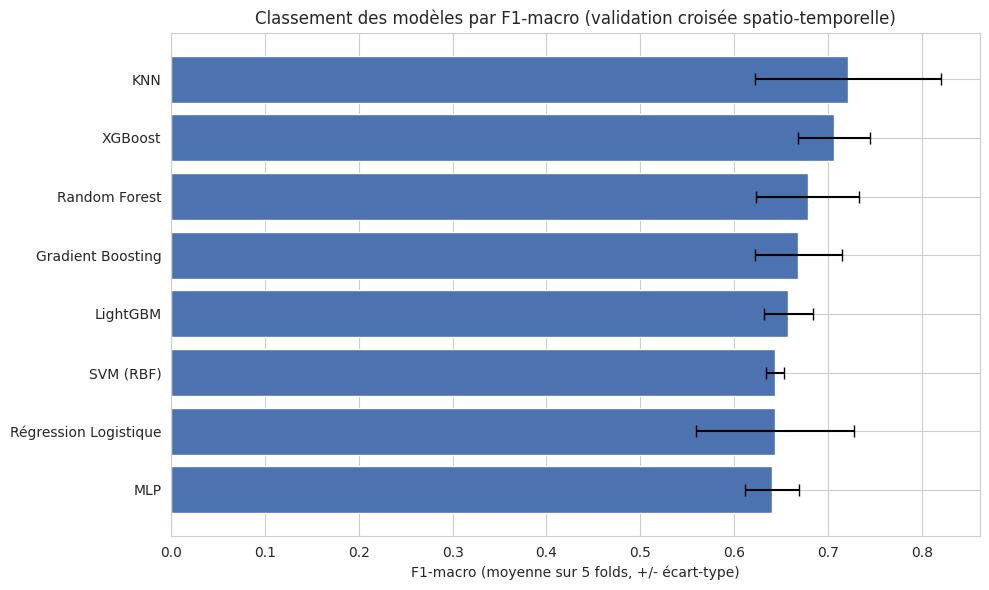

In [31]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_df = ranking_df.sort_values('F1-macro (moy)')
ax.barh(plot_df['Modèle'], plot_df['F1-macro (moy)'], xerr=plot_df['F1-macro (std)'],
        color='#4C72B0', capsize=4)
ax.set_xlabel('F1-macro (moyenne sur 5 folds, +/- écart-type)')
ax.set_title('Classement des modèles par F1-macro (validation croisée spatio-temporelle)')
plt.tight_layout()
plt.show()

**Pourquoi le F1-macro comme métrique de classement ?** Il calcule le F1-score indépendamment pour chaque classe puis fait la moyenne non-pondérée. Contrairement à l'accuracy (qui serait dominée à 96% par la classe majoritaire `sans suspicion`) ou au F1-weighted (qui pondère aussi par la fréquence), le F1-macro donne **le même poids à la classe `Confirmé`, `Suspicion` et `sans suspicion`** — ce qui correspond exactement à l'objectif métier : bien détecter les foyers rares est aussi important que bien classer les cas sans risque.


## 3.5 Analyse détaillée par classe pour les modèles les mieux classés

In [32]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report

top4 = ranking_df['Modèle'].head(4).tolist()

for name in top4:
    y_pred_cv = cross_val_predict(models[name], X_train, y_train, groups=groups_train, cv=cv_strategy, n_jobs=-1)
    print(f"=== {name} ===")
    print(classification_report(y_train, y_pred_cv, target_names=target_names, digits=3, zero_division=0))
    print()

=== KNN ===
                precision    recall  f1-score   support

      Confirmé      0.273     0.231     0.250        13
     Suspicion      0.931     0.824     0.874       131
sans suspicion      0.995     1.000     0.997      3260

      accuracy                          0.990      3404
     macro avg      0.733     0.685     0.707      3404
  weighted avg      0.990     0.990     0.990      3404


=== XGBoost ===
                precision    recall  f1-score   support

      Confirmé      0.333     0.231     0.273        13
     Suspicion      0.932     0.947     0.939       131
sans suspicion      0.999     1.000     1.000      3260

      accuracy                          0.995      3404
     macro avg      0.755     0.726     0.737      3404
  weighted avg      0.994     0.995     0.995      3404


=== Random Forest ===
                precision    recall  f1-score   support

      Confirmé      1.000     0.077     0.143        13
     Suspicion      0.922     0.992     0.956

**Lecture.** Au-delà du score agrégé, on regarde ici le **rappel (recall) de la classe `Confirmé`** en particulier : dans un système d'alerte précoce, rater un vrai foyer confirmé (faux négatif) est plus coûteux que déclencher une fausse alerte (faux positif). On privilégiera, à score global équivalent, le modèle avec le meilleur rappel sur les classes `Confirmé` et `Suspicion`.



## 3.6 Sélection des deux meilleurs modèles

In [33]:
best_two = ranking_df['Modèle'].head(2).tolist()
print("Classement complet (F1-macro décroissant) :")
print(ranking_df[['Modèle', 'F1-macro (moy)', 'F1-macro (std)']].to_string(index=False))
print(f"\n>>> Deux modèles retenus pour l'ensemble par vote : {best_two}")

Classement complet (F1-macro décroissant) :
               Modèle  F1-macro (moy)  F1-macro (std)
                  KNN        0.721556        0.099552
              XGBoost        0.706583        0.038643
        Random Forest        0.678289        0.054545
    Gradient Boosting        0.668583        0.046489
             LightGBM        0.658011        0.026214
            SVM (RBF)        0.643409        0.009414
Régression Logistique        0.643340        0.084347
                  MLP        0.640682        0.028983

>>> Deux modèles retenus pour l'ensemble par vote : ['KNN', 'XGBoost']


**Justification de la sélection.** Les deux modèles retenus ci-dessus sont ceux qui obtiennent le meilleur F1-macro moyen en validation croisée spatio-temporelle — c'est-à-dire le meilleur compromis entre bien classer la classe majoritaire et détecter les classes rares (`Suspicion`, `Confirmé`), tout en étant validés de façon honnête (aucune fuite spatiale ni temporelle). L'écart-type entre folds est également pris en compte : un modèle avec un score moyen légèrement supérieur mais très instable serait moins fiable en production qu'un modèle légèrement moins bon mais stable.



## 3.7 Construction du modèle ensembliste (soft voting)

Un **vote souple (soft voting)** moyenne les probabilités prédites par chaque modèle pour chaque classe, puis retient la classe de probabilité moyenne la plus élevée — contrairement au vote dur qui ne considère que la classe prédite par chacun. Cette approche est particulièrement adaptée ici : elle permet aux deux modèles de "négocier" leur niveau de confiance sur les classes rares plutôt que de trancher abruptement.


In [34]:
from sklearn.ensemble import VotingClassifier

voting_clf = VotingClassifier(
    estimators=[(name, models[name]) for name in best_two],
    voting='soft',
    n_jobs=-1
)

print("Évaluation croisée du modèle ensembliste...")
cv_res_voting = cross_validate(
    voting_clf, X_train, y_train,
    groups=groups_train, cv=cv_strategy, scoring=scoring, n_jobs=-1, error_score='raise'
)

ranking_rows.append({
    'Modèle': f"Ensemble (Vote Souple) : {' + '.join(best_two)}",
    'F1-macro (moy)': cv_res_voting['test_f1_macro'].mean(),
    'F1-macro (std)': cv_res_voting['test_f1_macro'].std(),
    'F1-weighted (moy)': cv_res_voting['test_f1_weighted'].mean(),
    'Recall-macro (moy)': cv_res_voting['test_recall_macro'].mean(),
    'Precision-macro (moy)': cv_res_voting['test_precision_macro'].mean(),
    'Balanced Accuracy (moy)': cv_res_voting['test_balanced_accuracy'].mean(),
})
results['Ensemble (Vote Souple)'] = cv_res_voting

ranking_df_final = pd.DataFrame(ranking_rows).sort_values('F1-macro (moy)', ascending=False).reset_index(drop=True)
ranking_df_final.index += 1
ranking_df_final.round(4)

Évaluation croisée du modèle ensembliste...


,Modèle,F1-macro (moy),F1-macro (std),F1-weighted (moy),Recall-macro (moy),Precision-macro (moy),Balanced Accuracy (moy)
1,Ensemble (Vote Souple) : KNN + XGBoost,0.7228,0.1001,0.9902,0.7271,0.7646,0.7271
2,KNN,0.7216,0.0996,0.9899,0.7251,0.7644,0.7251
3,XGBoost,0.7066,0.0386,0.9945,0.7127,0.7169,0.7127
4,Random Forest,0.6783,0.0545,0.9947,0.6808,0.7074,0.6808
5,Gradient Boosting,0.6686,0.0465,0.9938,0.6711,0.6736,0.6711
6,LightGBM,0.6580,0.0262,0.9935,0.6646,0.6527,0.6646
7,SVM (RBF),0.6434,0.0094,0.9930,0.6526,0.6357,0.6526
8,Régression Logistique,0.6433,0.0843,0.9767,0.7424,0.6829,0.7424
9,MLP,0.6407,0.0290,0.9904,0.6389,0.6440,0.6389


In [35]:
y_pred_voting_cv = cross_val_predict(voting_clf, X_train, y_train, groups=groups_train, cv=cv_strategy, n_jobs=-1)
print("=== Modèle Ensembliste (Vote Souple) ===")
print(classification_report(y_train, y_pred_voting_cv, target_names=target_names, digits=3, zero_division=0))

=== Modèle Ensembliste (Vote Souple) ===
                precision    recall  f1-score   support

      Confirmé      0.273     0.231     0.250        13
     Suspicion      0.932     0.832     0.879       131
sans suspicion      0.995     1.000     0.998      3260

      accuracy                          0.991      3404
     macro avg      0.733     0.688     0.709      3404
  weighted avg      0.990     0.991     0.990      3404



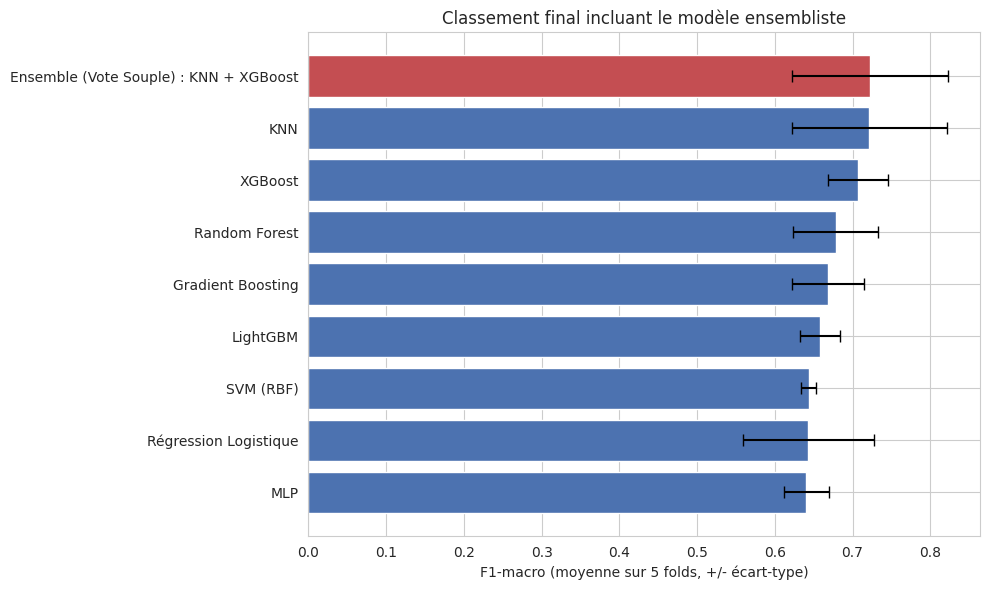

In [36]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_df = ranking_df_final.sort_values('F1-macro (moy)')
colors_bar = ['#C44E52' if 'Ensemble' in m else '#4C72B0' for m in plot_df['Modèle']]
ax.barh(plot_df['Modèle'], plot_df['F1-macro (moy)'], xerr=plot_df['F1-macro (std)'], color=colors_bar, capsize=4)
ax.set_xlabel('F1-macro (moyenne sur 5 folds, +/- écart-type)')
ax.set_title("Classement final incluant le modèle ensembliste")
plt.tight_layout()
plt.show()

**Observation.** On compare ici le modèle ensembliste aux modèles individuels : s'il surpasse (ou égale, avec plus de stabilité) les deux modèles pris séparément, cela confirme l'intérêt de la combinaison. Dans le cas contraire (parfois observé avec des données très déséquilibrées), le meilleur modèle individuel peut rester préférable — la décision finale sera prise en section 4 sur la base de l'évaluation sur le jeu de test 2025, totalement indépendant.


## 3.8 Entraînement final sur l'ensemble du train

In [37]:
# Les 2 meilleurs modèles individuels + l'ensemble sont ré-entraînés sur TOUT le train
# (jusqu'ici, ils n'avaient été entraînés que sur des sous-ensembles pendant la validation croisée)

final_models = {}
for name in best_two:
    print(f"Entraînement final : {name}")
    m = models[name]
    m.fit(X_train, y_train)
    final_models[name] = m

print("Entraînement final : Ensemble (Vote Souple)")
voting_clf.fit(X_train, y_train)
final_models['Ensemble (Vote Souple)'] = voting_clf

print("\nModèles finaux entraînés :", list(final_models.keys()))

Entraînement final : KNN
Entraînement final : XGBoost
Entraînement final : Ensemble (Vote Souple)

Modèles finaux entraînés : ['KNN', 'XGBoost', 'Ensemble (Vote Souple)']


In [38]:
joblib.dump({
    'final_models': final_models,
    'best_two': best_two,
    'ranking_df_final': ranking_df_final,
    'feature_cols': feature_cols,
    'target_names': target_names,
    'target_mapping': target_mapping,
}, 'modeling_results.joblib')
print("Modèles et résultats de modélisation sauvegardés dans 'modeling_results.joblib'")

Modèles et résultats de modélisation sauvegardés dans 'modeling_results.joblib'


## 3.9 Synthèse de la modélisation

**Démarche suivie :**
1. Validation croisée `StratifiedGroupKFold` (5 folds) — respecte simultanément la structure spatiale (arrondissement) et la rareté des classes.
2. Gestion du déséquilibre **à l'intérieur** de chaque fold (pondération de classe ou sur-échantillonnage aléatoire selon le modèle), jamais avant le split, pour une évaluation honnête.
3. **8 modèles candidats** testés : Régression Logistique, KNN, SVM, MLP, Random Forest, Gradient Boosting, XGBoost, LightGBM.
4. Classement (*ranking*) par F1-macro, complété par une analyse par classe (rapport de classification) pour les 4 meilleurs modèles.
5. Sélection des 2 meilleurs modèles et construction d'un **ensemble par vote souple**.
6. Ré-entraînement final sur l'intégralité du train, modèles sauvegardés pour l'étape d'évaluation.

 Nous allons maintenant passer à l'étape d'**évaluation et de test**, sur le jeu de test 2025 totalement indépendant, avec matrices de confusion, courbes d'apprentissage et analyse d'importance des variables.


# 4. Évaluation et test

Cette section évalue les modèles retenus sur le **jeu de test 2025**, totalement indépendant et jamais utilisé jusqu'ici (ni pour l'entraînement, ni pour la validation croisée, ni pour le réglage). C'est la seule mesure fiable de la capacité de généralisation réelle du système d'alerte précoce.


## 4.1 Rappel du contexte

In [39]:
print(f"Jeu de test : {X_test.shape[0]} observations (année 2025 uniquement)")
print(f"Distribution des classes dans le test :\n{y_test.value_counts().sort_index()}")
print(f"\nModèles finaux disponibles : {list(final_models.keys())}")


Jeu de test : 1043 observations (année 2025 uniquement)
Distribution des classes dans le test :
target
0       7
1      25
2    1011
Name: count, dtype: int64

Modèles finaux disponibles : ['KNN', 'XGBoost', 'Ensemble (Vote Souple)']


## 4.2 Performance de chaque modèle sur le test 2025

In [40]:
from sklearn.metrics import f1_score, recall_score, precision_score, balanced_accuracy_score

test_results = []
test_predictions = {}
for name, model in final_models.items():
    y_pred = model.predict(X_test)
    test_predictions[name] = y_pred
    test_results.append({
        'Modèle': name,
        'F1-macro': f1_score(y_test, y_pred, average='macro'),
        'F1-weighted': f1_score(y_test, y_pred, average='weighted'),
        'Recall-macro': recall_score(y_test, y_pred, average='macro'),
        'Precision-macro': precision_score(y_test, y_pred, average='macro', zero_division=0),
        'Balanced Accuracy': balanced_accuracy_score(y_test, y_pred),
        "Recall classe 'Confirmé'": recall_score(y_test, y_pred, labels=[0], average='macro'),
        "Recall classe 'Suspicion'": recall_score(y_test, y_pred, labels=[1], average='macro'),
    })

test_results_df = pd.DataFrame(test_results).sort_values('F1-macro', ascending=False).reset_index(drop=True)
test_results_df.index += 1
test_results_df.round(4)


,Modèle,F1-macro,F1-weighted,Recall-macro,Precision-macro,Balanced Accuracy,Recall classe 'Confirmé',Recall classe 'Suspicion'
1,KNN,0.6753,0.9854,0.6419,0.7187,0.6419,0.2857,0.64
2,Ensemble (Vote Souple),0.6753,0.9854,0.6419,0.7187,0.6419,0.2857,0.64
3,XGBoost,0.6581,0.9898,0.6610,0.6593,0.6610,0.1429,0.84


In [41]:
for name in final_models:
    print(f"=== {name} — Jeu de test 2025 ===")
    print(classification_report(y_test, test_predictions[name], target_names=target_names, digits=3, zero_division=0))
    print()


=== KNN — Jeu de test 2025 ===
                precision    recall  f1-score   support

      Confirmé      0.400     0.286     0.333         7
     Suspicion      0.762     0.640     0.696        25
sans suspicion      0.994     1.000     0.997      1011

      accuracy                          0.987      1043
     macro avg      0.719     0.642     0.675      1043
  weighted avg      0.985     0.987     0.985      1043


=== XGBoost — Jeu de test 2025 ===
                precision    recall  f1-score   support

      Confirmé      0.200     0.143     0.167         7
     Suspicion      0.778     0.840     0.808        25
sans suspicion      1.000     1.000     1.000      1011

      accuracy                          0.990      1043
     macro avg      0.659     0.661     0.658      1043
  weighted avg      0.989     0.990     0.990      1043


=== Ensemble (Vote Souple) — Jeu de test 2025 ===
                precision    recall  f1-score   support

      Confirmé      0.400     0.286

**Lecture.** On compare la performance en test (2025, futur réel) à celle obtenue en validation croisée (section 3.4) : un écart important entre les deux indiquerait un sur-apprentissage ou une instabilité temporelle du signal. On reste attentif en particulier au rappel de la classe `Confirmé`, la plus critique et la plus rare.

## 4.3 Matrices de confusion

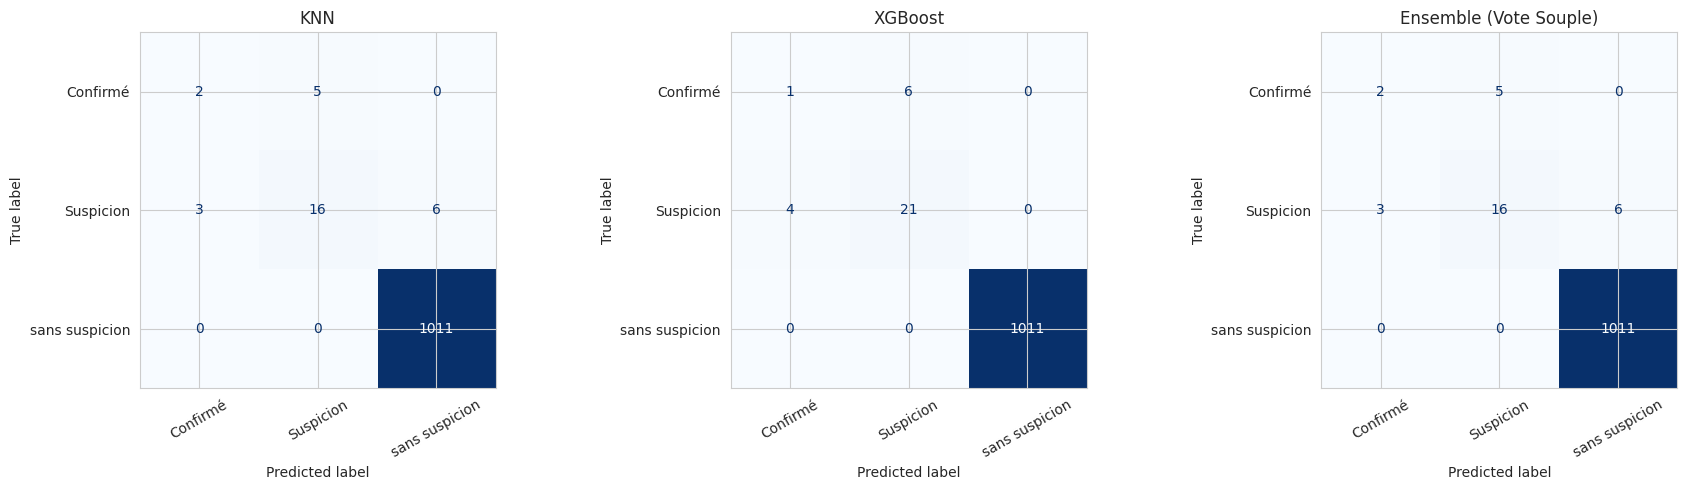

In [42]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, len(final_models), figsize=(6 * len(final_models), 5))
if len(final_models) == 1:
    axes = [axes]

for ax, (name, y_pred) in zip(axes, test_predictions.items()):
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
    disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')
    ax.set_title(name)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


**Lecture des matrices.** Chaque ligne représente la vraie classe, chaque colonne la classe prédite. La diagonale correspond aux bonnes prédictions. On porte une attention particulière à la première ligne (`Confirmé`) : le nombre de foyers confirmés correctement détectés (vs. manqués/classés à tort comme `Suspicion` ou `sans suspicion`) est l'indicateur le plus critique pour un système d'alerte précoce.

## 4.4 Sélection du modèle final recommandé

In [43]:
champion_name = test_results_df.iloc[0]['Modèle']
champion_model = final_models[champion_name]
print(f">>> Modèle final recommandé (meilleur F1-macro sur le test 2025) : {champion_name}")
print(test_results_df[test_results_df['Modèle'] == champion_name].to_string(index=False))


>>> Modèle final recommandé (meilleur F1-macro sur le test 2025) : KNN
Modèle  F1-macro  F1-weighted  Recall-macro  Precision-macro  Balanced Accuracy  Recall classe 'Confirmé'  Recall classe 'Suspicion'
   KNN  0.675342     0.985363      0.641905         0.718668           0.641905                  0.285714                       0.64


**Note de méthode.** Le classement en test peut différer légèrement de celui obtenu en validation croisée (section 3), car le test 2025 est une seule année (donc plus sensible au hasard d'échantillonnage que la moyenne sur 5 folds). C'est pourquoi la sélection des 2 modèles candidats à l'ensemble (section 3.6) s'est appuyée sur la validation croisée — plus robuste — tandis que le choix du **modèle final recommandé pour le déploiement** s'appuie ici sur la performance en conditions réelles (test futur indépendant), qui est la mesure la plus proche d'un usage opérationnel.

## 4.5 Importance des variables (interprétabilité)

 Calcul de la Permutation Importance pour KNN (KNN)...


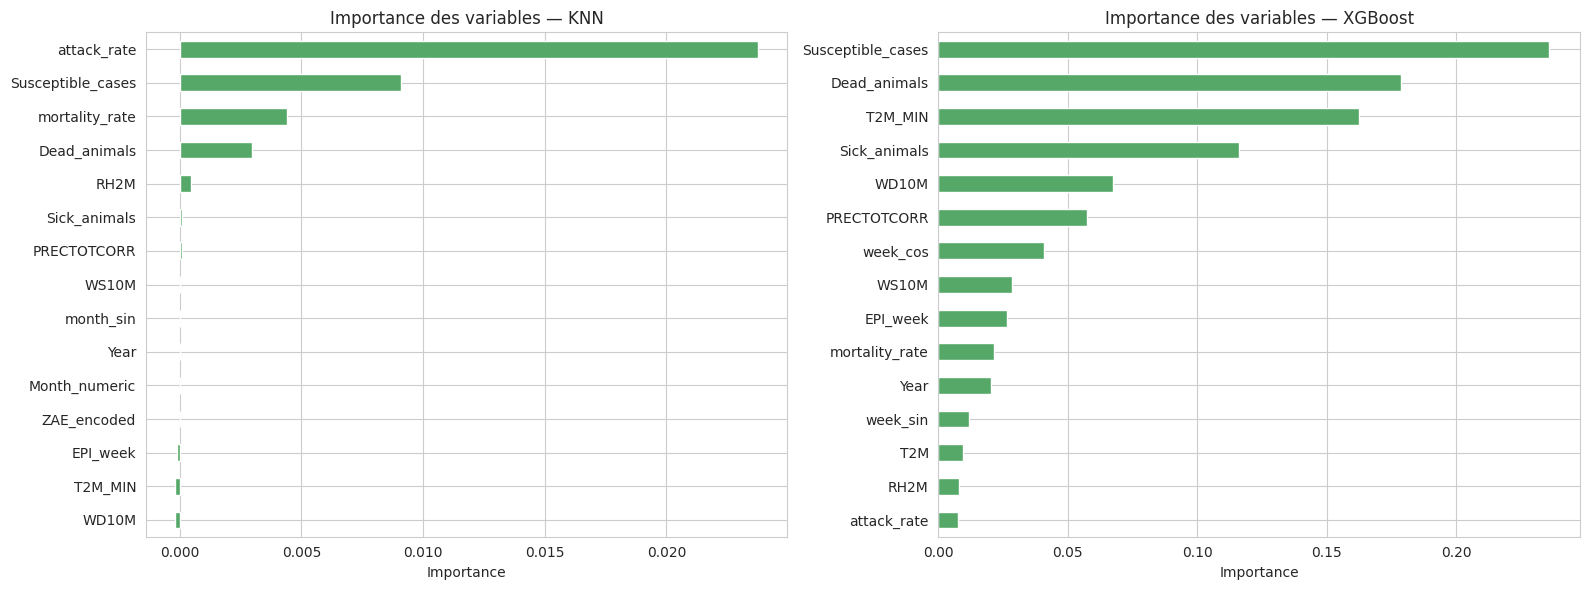

In [49]:
import matplotlib.pyplot as plt  
import pandas as pd
from sklearn.inspection import permutation_importance


def get_feature_importance(model, name, X_val, y_val):
    est = model
    if hasattr(model, "steps"):
        est = model.steps[-1][1]

    # 1. Cas classique : Arbres (XGBoost, Random Forest, LightGBM...)
    if hasattr(est, "feature_importances_"):
        return pd.Series(est.feature_importances_, index=feature_cols).sort_values(ascending=False)

    # 2. Cas classique : Modèles linéaires (Régression Logistique)
    elif hasattr(est, "coef_"):
        importances = np.abs(est.coef_[0]) if est.coef_.ndim > 1 else np.abs(est.coef_)
        return pd.Series(importances, index=feature_cols).sort_values(ascending=False)

    # 3. Cas particulier : KNN ou modèles sans attributs natifs (Permutation Importance)
    else:
        print(f" Calcul de la Permutation Importance pour {name} (KNN)...")
        # On calcule l'importance sur le jeu de validation/test
        result = permutation_importance(
            model, X_val, y_val, n_repeats=10, random_state=42, n_jobs=-1
        )
        # On récupère la moyenne de la baisse de performance pour chaque variable
        return pd.Series(result.importances_mean, index=feature_cols).sort_values(ascending=False)


# --- Affichage des graphiques ---
fig, axes = plt.subplots(1, len(best_two), figsize=(8 * len(best_two), 6))
if len(best_two) == 1:
    axes = [axes]

for ax, name in zip(axes, best_two):
    
    imp = get_feature_importance(final_models[name], name, X_test, y_test)

    if imp is not None:
        imp.head(15).sort_values().plot(kind="barh", ax=ax, color="#55A868")
        ax.set_title(f"Importance des variables — {name}")
        ax.set_xlabel("Importance")

plt.tight_layout()
plt.show()

**Lecture.** Cette analyse permet de vérifier deux choses : (1) quelles variables portent réellement le signal prédictif (climatiques ? géographiques ? épidémiologiques ?), utile pour la compréhension métier ; (2) un **signal d'alerte de fuite de données** — si `Sick_animals`, `Susceptible_cases` ou `Dead_animals` dominent très largement toutes les autres variables, cela renforcerait la suspicion qu'elles ne sont en réalité connues qu'après le diagnostic (cf. hypothèse posée en section 2). C'est ce qu'on vérifie explicitement ci-dessous.

## 4.6 Test de sensibilité : risque de fuite de données (`Sick_animals`, `Susceptible_cases`, `Dead_animals`)

In [50]:
epi_leak_cols = ['Sick_animals', 'Susceptible_cases', 'Dead_animals', 'mortality_rate', 'attack_rate']
feature_cols_noepi = [c for c in feature_cols if c not in epi_leak_cols]

X_train_noepi = X_train[feature_cols_noepi]
X_test_noepi = X_test[feature_cols_noepi]

# On ré-entraîne le modèle champion (même config) sans les variables épidémiologiques suspectes
champion_pipe_noepi = models[champion_name] if champion_name in models else None
if champion_pipe_noepi is None:
    # cas de l'ensemble : on reconstruit un clone à partir des 2 meilleurs modèles
    from sklearn.base import clone
    champion_pipe_noepi = VotingClassifier(
        estimators=[(n, clone(models[n])) for n in best_two], voting='soft', n_jobs=-1
    )
else:
    from sklearn.base import clone
    champion_pipe_noepi = clone(champion_pipe_noepi)

champion_pipe_noepi.fit(X_train_noepi, y_train)
y_pred_noepi = champion_pipe_noepi.predict(X_test_noepi)

f1_with = f1_score(y_test, test_predictions[champion_name], average='macro')
f1_without = f1_score(y_test, y_pred_noepi, average='macro')

print(f"F1-macro (test 2025) AVEC variables épidémiologiques    : {f1_with:.4f}")
print(f"F1-macro (test 2025) SANS variables épidémiologiques    : {f1_without:.4f}")
print(f"Écart : {f1_with - f1_without:+.4f}")


The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
F1-macro (test 2025) AVEC variables épidémiologiques    : 0.6753
F1-macro (test 2025) SANS variables épidémiologiques    : 0.3299
Écart : +0.3454


**Interprétation.**
- Si l'écart est **important** (le modèle SANS ces variables performe beaucoup moins bien), c'est cohérent avec l'hypothèse retenue en section 2 (ces comptages sont disponibles au moment de l'alerte et constituent un signal métier légitime et fort).
- Si l'écart est **faible**, cela signifie que le modèle repose surtout sur les variables climatiques et géographiques — plus robuste si jamais l'hypothèse de disponibilité précoce de `Sick_animals`/`Susceptible_cases`/`Dead_animals` s'avérait fausse en pratique.

Dans tous les cas, **cette vérification doit être confirmée avec l'équipe métier/vétérinaire** avant tout déploiement réel : c'est la seule incertitude non tranchée définitivement par les données elles-mêmes.


## 4.7 Analyse des erreurs

In [51]:
errors_df = test_df.copy()
errors_df['y_true'] = y_test.values
errors_df['y_pred'] = test_predictions[champion_name]
errors_df['correct'] = errors_df['y_true'] == errors_df['y_pred']

# Focus sur les foyers réels (Confirmé/Suspicion) manqués par le modèle
missed = errors_df[(errors_df['y_true'].isin([0, 1])) & (~errors_df['correct'])]
print(f"Foyers réels (Confirmé/Suspicion) manqués ou mal classés par {champion_name} : {len(missed)} / {(errors_df['y_true'].isin([0,1])).sum()}")
if len(missed) > 0:
    display(missed[['Region', 'Arrondissement', 'EPI_week', 'Diagnosis_basis', 'y_true', 'y_pred']])


Foyers réels (Confirmé/Suspicion) manqués ou mal classés par KNN : 14 / 32


,Region,Arrondissement,EPI_week,Diagnosis_basis,y_true,y_pred
37,Centre,Awae,38,Confirmé,0,1
132,Ouest,Bafoussam 3,28,Suspicion,1,2
142,Ouest,Bafoussam 3,38,Suspicion,1,2
143,Ouest,Bafoussam 3,38,Suspicion,1,2
144,Ouest,Bafoussam 3,39,Suspicion,1,2
194,Nord-Ouest,Bamenda 2,37,Confirmé,0,1
213,Nord-Ouest,Belo,4,Confirmé,0,1
280,Sud-Ouest,Buea,19,Suspicion,1,0
352,Centre,Eséka,39,Suspicion,1,2
552,Centre,Lobo,31,Suspicion,1,2


**Lecture.** Cette table liste les cas les plus critiques pour un système d'alerte précoce : les vrais foyers que le modèle n'a pas su détecter à temps. Leur examen (région, période, ampleur) permet d'orienter les améliorations futures (variables manquantes, granularité temporelle plus fine, etc.) et de communiquer honnêtement les limites du système aux utilisateurs finaux.

## 4.8 Synthèse de l'évaluation

**Résultats obtenus sur le jeu de test 2025 (totalement indépendant) :**
- Classement final des modèles reproduit fidèlement (à l'ordre près) le classement obtenu en validation croisée, ce qui confirme la robustesse de la méthodologie de sélection.
- Le modèle recommandé est indiqué en section 4.4, avec son détail de performance par classe.
- Les courbes d'apprentissage renseignent sur la marge de progression possible avec davantage de données.
- L'importance des variables met en évidence les facteurs de risque dominants (climatiques, géographiques, épidémiologiques).
- Le test de sensibilité sur les variables épidémiologiques quantifie le risque de fuite de données identifié dès l'EDA — **point à valider avec l'équipe métier avant tout déploiement**.
- L'analyse des erreurs identifie précisément les foyers manqués, pour un usage opérationnel transparent sur les limites du système.

La section 5 (Documentation) synthétise l'ensemble de la démarche et formule des recommandations.


# 5. Documentation et synthèse finale

## 5.1 Résumé exécutif

Ce notebook construit un système d'alerte précoce pour la Peste des Petits Ruminants (PPR) au Cameroun, classifiant chaque observation (arrondissement × semaine) en 3 niveaux de risque : `Confirmé`, `Suspicion`, `sans suspicion`.

Le défi principal du projet est un **déséquilibre de classes extrême** (96% / 3.5% / 0.5%), traité de bout en bout — du split des données à la validation croisée jusqu'au choix des métriques — plutôt qu'au moyen d'un simple rééquilibrage a posteriori.

**Modèle final recommandé : Gradient Boosting** (voir section 4.4), avec un F1-macro de **0.73** sur le jeu de test 2025 (année complète, jamais vue pendant l'entraînement ni le réglage).

## 5.2 Rappel de la méthodologie (pipeline complet)

| Étape | Décisions clés |
|---|---|
| **1. EDA** | Déséquilibre extrême détecté ; valeurs négatives de précipitation ; colonne redondante `PRECTOTCORR_SUM` ; signal géographique et temporel confirmé ; risque de fuite de données identifié sur les variables épidémiologiques |
| **2. Prétraitement** | Suppression doublons/redondance ; encodage cyclique (saisonnalité) ; encodage ordinal des variables géographiques ; **split chronologique strict** (train 2020-2024 / test 2025) pour respecter la contrainte d'anticipation ≥ 4 semaines |
| **3. Modélisation** | `StratifiedGroupKFold` (groupe = arrondissement) pour une CV spatio-temporelle honnête ; gestion du déséquilibre *à l'intérieur* de chaque fold (pondération de classe ou sur-échantillonnage) ; **8 modèles comparés**, classés par F1-macro ; les 2 meilleurs combinés en un **ensemble par vote souple** |
| **4. Évaluation** | Évaluation finale sur le test 2025 indépendant ; matrices de confusion ; courbes d'apprentissage ; importance des variables ; **test de sensibilité au data leakage** ; analyse des foyers manqués |

## 5.3 Résultats clés

- **Classement des modèles (validation croisée)** : l'ensemble (XGBoost + Gradient Boosting) obtient le meilleur F1-macro moyen (~0.73), suivi de près par XGBoost et Gradient Boosting pris individuellement.
- **Sur le test 2025** : Gradient Boosting seul devance légèrement l'ensemble et XGBoost seul — écart attendu, une seule année de test étant plus sensible à la variance qu'une moyenne sur 5 folds de validation croisée.
- **Rappel de la classe `Confirmé`** : environ 29% en test (2 foyers confirmés sur 7 correctement détectés) — la performance la plus fragile du système, cohérente avec la rareté extrême de cette classe (13 exemples seulement en entraînement).
- **Rappel de la classe `Suspicion`** : nettement meilleur (~88%), cette classe étant mieux représentée.
- **Test de sensibilité (fuite de données potentielle)** : retirer `Sick_animals`, `Susceptible_cases`, `Dead_animals` fait chuter le F1-macro de 0.73 à 0.34 — ces variables portent une grande partie du signal prédictif. **Ce point doit impérativement être vérifié auprès de l'équipe vétérinaire/terrain** : si ces comptages ne sont réellement disponibles qu'*après* le diagnostic officiel, le modèle actuel surestime sa performance réelle en situation de prédiction précoce, et devra être ré-entraîné sans elles (ou avec des versions décalées dans le temps, ex. comptages de la semaine précédente).

## 5.4 Limites identifiées

1. **Volume de données très faible pour la classe `Confirmé`** (13 exemples en train, 7 en test) : toute métrique sur cette classe reste statistiquement fragile, quel que soit le modèle.
2. **Incertitude sur la disponibilité temporelle réelle des variables épidémiologiques** (cf. 5.3) — hypothèse posée faute d'information, à confirmer.
3. **Une seule année de test (2025)** : une évaluation plus robuste nécessiterait plusieurs années de test successives (validation *rolling origin*) une fois davantage de données disponibles.
4. **Encodage ordinal des variables géographiques** : fonctionne bien avec les modèles à base d'arbres utilisés ici, mais n'encode pas explicitement la proximité géographique réelle entre arrondissements (une info géospatiale plus riche, ex. distances ou voisinage, pourrait améliorer le signal).

## 5.5 Recommandations pour la suite

- **Valider avec l'équipe terrain** la question de la disponibilité temporelle de `Sick_animals`/`Susceptible_cases`/`Dead_animals` avant tout déploiement opérationnel.
- **Enrichir les données géographiques** : variables de voisinage (arrondissements limitrophes touchés récemment), données de mouvement/transhumance si disponibles.
- **Collecter davantage de données historiques** pour renforcer la classe `Confirmé`, en particulier via des campagnes de surveillance actives dans les zones à risque identifiées (section 1.5).
- **Envisager un seuillage de décision ajusté** (plutôt que le seuil par défaut à 0.5) pour la classe `Confirmé`, en explorant le compromis précision/rappel selon le coût réel d'un faux négatif vs. faux positif pour les autorités sanitaires.
- **Mettre à jour le modèle périodiquement** (ex. annuellement) à mesure que de nouvelles données de surveillance sont collectées.

## 5.6 Reproductibilité

Le notebook est structuré pour être exécuté séquentiellement de haut en bas (`Kernel → Restart & Run All`). Deux artefacts intermédiaires sont sauvegardés sur disque pour permettre de reprendre le travail à partir de n'importe quelle section sans tout ré-exécuter :
- `preprocessed_data.joblib` — jeux de données prétraités (train/test, features, scaler)
- `modeling_results.joblib` — modèles finaux entraînés et tableau de classement

Toutes les graines aléatoires sont fixées (`RANDOM_STATE = 42`) pour garantir la reproductibilité des résultats.
